# 🔬 INDIA.RUNS 2026 – RedrRob AI Challenge
## Deep Dataset Forensics & Profile Analysis

**Objective:** Understand the candidate dataset completely before any feature engineering.  
**Target Role:** Senior AI Engineer  
**Evaluation Metric:** NDCG@10  

---
> This notebook performs exhaustive dataset forensics: schema validation, missingness analysis,  
> distribution profiling, duplicate detection, and honeypot signal identification.


In [1]:
import json
import math
import warnings
from collections import Counter, defaultdict
from datetime import datetime, date
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm

warnings.filterwarnings("ignore")

# ── Aesthetics ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#0f1117",
    "axes.edgecolor":   "#444",
    "axes.labelcolor":  "#ddd",
    "xtick.color":      "#aaa",
    "ytick.color":      "#aaa",
    "text.color":       "#eee",
    "grid.color":       "#2a2a2a",
    "grid.linestyle":   "--",
    "grid.linewidth":   0.6,
    "legend.facecolor": "#1a1a2e",
    "legend.edgecolor": "#444",
    "font.family":      "DejaVu Sans",
})
PALETTE   = ["#7B5EA7", "#4ECDC4", "#FF6B6B", "#FFE66D", "#45B7D1",
             "#96CEB4", "#FFEAA7", "#DDA0DD", "#98D8C8", "#F7DC6F"]
ACCENT    = "#7B5EA7"
WARN_CLR  = "#FF6B6B"
GOOD_CLR  = "#4ECDC4"

DATA_PATH = Path("candidates.jsonl")
TODAY     = date(2026, 6, 23)   # competition reference date
print(f"✅ Libraries loaded  |  Reference date: {TODAY}")


✅ Libraries loaded  |  Reference date: 2026-06-23


## 1. Load & Parse Dataset

In [2]:
candidates = []
parse_errors = []

with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line_no, line in enumerate(tqdm(f, desc="Loading JSONL"), 1):
        line = line.strip()
        if not line:
            continue
        try:
            candidates.append(json.loads(line))
        except json.JSONDecodeError as e:
            parse_errors.append((line_no, str(e)))

print(f"\n{'='*55}")
print(f"  Total records loaded : {len(candidates):,}")
print(f"  JSON parse errors    : {len(parse_errors)}")
print(f"  File size            : {DATA_PATH.stat().st_size / 1e6:.1f} MB")
print(f"{'='*55}")


Loading JSONL: 0it [00:00, ?it/s]

Loading JSONL: 2851it [00:00, 28503.98it/s]

Loading JSONL: 5842it [00:00, 29328.36it/s]

Loading JSONL: 8775it [00:00, 21227.09it/s]

Loading JSONL: 11099it [00:00, 18910.80it/s]

...

Loading JSONL: 93922it [00:05, 18657.48it/s]

Loading JSONL: 96223it [00:05, 19637.01it/s]

Loading JSONL: 98511it [00:05, 17254.90it/s]

Loading JSONL: 100000it [00:05, 16914.66it/s]


  Total records loaded : 100,000
  JSON parse errors    : 0
  File size            : 487.3 MB


## 2. Schema Exploration

In [3]:
sample = candidates[0]
top_keys = list(sample.keys())
print("Top-level keys:", top_keys)
print()

# field presence across ALL records
key_presence = {k: sum(1 for c in candidates if k in c) for k in top_keys}
for k, v in key_presence.items():
    pct = v / len(candidates) * 100
    status = "✅" if pct == 100 else "⚠️ "
    print(f"  {status} {k:<35s}  {v:,} / {len(candidates):,}  ({pct:.1f}%)")


Top-level keys: ['candidate_id', 'profile', 'career_history', 'education', 'skills', 'certifications', 'languages', 'redrob_signals']

  ✅ candidate_id                         100,000 / 100,000  (100.0%)
  ✅ profile                              100,000 / 100,000  (100.0%)
  ✅ career_history                       100,000 / 100,000  (100.0%)


  ✅ education                            100,000 / 100,000  (100.0%)
  ✅ skills                               100,000 / 100,000  (100.0%)
  ✅ certifications                       100,000 / 100,000  (100.0%)
  ✅ languages                            100,000 / 100,000  (100.0%)
  ✅ redrob_signals                       100,000 / 100,000  (100.0%)


In [4]:
def extract_flat(c):
    p  = c.get("profile", {})
    rs = c.get("redrob_signals", {})
    sal = rs.get("expected_salary_range_inr_lpa", {}) or {}
    skill_names  = [s["name"] for s in c.get("skills", [])]
    skill_levels = [s.get("proficiency") for s in c.get("skills", [])]
    edu          = c.get("education", [])
    career       = c.get("career_history", [])
    certs        = c.get("certifications", [])
    langs        = c.get("languages", [])
    assessment   = rs.get("skill_assessment_scores", {}) or {}

    # Total career months from records
    total_career_months = sum(j.get("duration_months", 0) or 0 for j in career)

    # Companies
    companies = [j.get("company", "") for j in career]

    return {
        # Identity
        "candidate_id":                 c.get("candidate_id"),
        # Profile
        "location":                     p.get("location"),
        "country":                      p.get("country"),
        "years_of_experience":          p.get("years_of_experience"),
        "current_title":                p.get("current_title"),
        "current_company":              p.get("current_company"),
        "current_company_size":         p.get("current_company_size"),
        "current_industry":             p.get("current_industry"),
        # Career
        "n_jobs":                       len(career),
        "total_career_months":          total_career_months,
        "implied_exp_years":            round(total_career_months / 12, 2),
        "companies_str":                "|".join(companies),
        "unique_companies":             len(set(companies)),
        # Education
        "n_edu":                        len(edu),
        "highest_tier":                 min((e.get("tier","tier_4") for e in edu),
                                           key=lambda t: {"tier_1":1,"tier_2":2,
                                                          "tier_3":3,"tier_4":4,"unknown":5}.get(t,5))
                                           if edu else "none",
        # Skills
        "n_skills":                     len(skill_names),
        "n_expert_skills":              skill_levels.count("expert"),
        "n_advanced_skills":            skill_levels.count("advanced"),
        "skills_str":                   "|".join(skill_names),
        # Certifications & Languages
        "n_certs":                      len(certs),
        "n_langs":                      len(langs),
        # Redrob signals
        "profile_completeness":         rs.get("profile_completeness_score"),
        "open_to_work":                 rs.get("open_to_work_flag"),
        "profile_views_30d":            rs.get("profile_views_received_30d"),
        "applications_30d":             rs.get("applications_submitted_30d"),
        "recruiter_response_rate":      rs.get("recruiter_response_rate"),
        "avg_response_time_hours":      rs.get("avg_response_time_hours"),
        "connection_count":             rs.get("connection_count"),
        "endorsements_received":        rs.get("endorsements_received"),
        "notice_period_days":           rs.get("notice_period_days"),
        "salary_min":                   sal.get("min"),
        "salary_max":                   sal.get("max"),
        "preferred_work_mode":          rs.get("preferred_work_mode"),
        "willing_to_relocate":          rs.get("willing_to_relocate"),
        "github_activity_score":        rs.get("github_activity_score"),
        "search_appearance_30d":        rs.get("search_appearance_30d"),
        "saved_by_recruiters_30d":      rs.get("saved_by_recruiters_30d"),
        "interview_completion_rate":    rs.get("interview_completion_rate"),
        "offer_acceptance_rate":        rs.get("offer_acceptance_rate"),
        "verified_email":               rs.get("verified_email"),
        "verified_phone":               rs.get("verified_phone"),
        "linkedin_connected":           rs.get("linkedin_connected"),
        "n_assessments":                len(assessment),
        "avg_assessment_score":         np.mean(list(assessment.values())) if assessment else np.nan,
        "signup_date":                  rs.get("signup_date"),
        "last_active_date":             rs.get("last_active_date"),
    }

rows = [extract_flat(c) for c in tqdm(candidates, desc="Flattening")]
df = pd.DataFrame(rows)

# Parse dates
df["signup_date"]      = pd.to_datetime(df["signup_date"], errors="coerce")
df["last_active_date"] = pd.to_datetime(df["last_active_date"], errors="coerce")
df["days_since_active"]= (pd.Timestamp(TODAY) - df["last_active_date"]).dt.days
df["days_since_signup"] = (pd.Timestamp(TODAY) - df["signup_date"]).dt.days

print(f"DataFrame shape: {df.shape}")
df.head(3)


Flattening:   0%|          | 0/100000 [00:00<?, ?it/s]

Flattening:  10%|█         | 10195/100000 [00:00<00:00, 101947.18it/s]

Flattening:  20%|██        | 20390/100000 [00:00<00:01, 70926.90it/s] 

Flattening:  28%|██▊       | 28028/100000 [00:00<00:01, 63377.80it/s]

Flattening:  35%|███▌      | 35130/100000 [00:00<00:00, 65776.85it/s]

...

Flattening:  92%|█████████▏| 91707/100000 [00:01<00:00, 63248.73it/s]

Flattening: 100%|█████████▉| 99907/100000 [00:01<00:00, 68426.15it/s]

Flattening: 100%|██████████| 100000/100000 [00:01<00:00, 62812.79it/s]

DataFrame shape: (100000, 48)


,candidate_id,location,country,years_of_experience,current_title,current_company,current_company_size,current_industry,n_jobs,total_career_months,...,offer_acceptance_rate,verified_email,verified_phone,linkedin_connected,n_assessments,avg_assessment_score,signup_date,last_active_date,days_since_active,days_since_signup
0,CAND_0000001,Toronto,Canada,6.9,Backend Engineer,Mindtree,10001+,IT Services,2,82,...,0.58,True,True,False,4,49.725,2025-10-16,2026-05-20,34,250
1,CAND_0000002,"Chennai, Tamil Nadu",India,12.5,Operations Manager,Wipro,10001+,IT Services,4,149,...,-1.00,False,False,False,0,NaN,2025-07-28,2025-11-12,223,330
2,CAND_0000003,Austin,USA,1.1,Customer Support,TCS,10001+,IT Services,1,13,...,-1.00,True,False,False,0,NaN,2024-08-02,2026-03-21,94,690


## 3. Missing Value Report

Columns with ANY missing values: 1


,Missing Count,Missing %
avg_assessment_score,75756,75.76


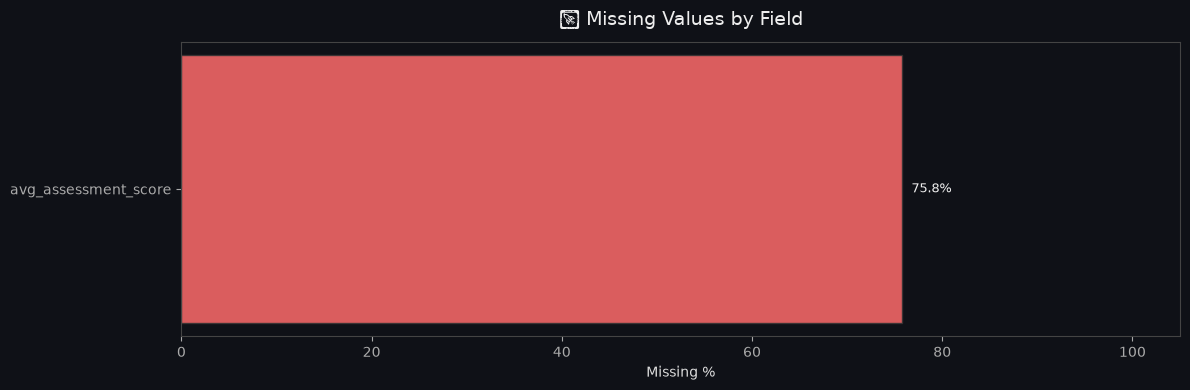

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
mv_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
mv_df = mv_df[mv_df["Missing Count"] > 0]

print(f"Columns with ANY missing values: {len(mv_df)}")
display(mv_df)

# Visualise missing values
if len(mv_df) > 0:
    fig, ax = plt.subplots(figsize=(12, max(4, len(mv_df)*0.4)))
    bars = ax.barh(mv_df.index, mv_df["Missing %"], color=WARN_CLR, edgecolor="#333", alpha=0.85)
    ax.set_xlabel("Missing %")
    ax.set_title("🚨 Missing Values by Field", fontsize=14, color="#eee", pad=12)
    ax.set_xlim(0, 105)
    for bar, val in zip(bars, mv_df["Missing %"]):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f"{val:.1f}%", va="center", fontsize=9, color="#eee")
    plt.tight_layout()
    plt.savefig("missing_values.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
    plt.show()
else:
    print("✅ No missing values in flattened fields!")


## 4. Duplicate & ID Integrity Check

In [6]:
# Exact ID duplicates
dup_ids = df[df.duplicated("candidate_id", keep=False)]["candidate_id"].unique()
print(f"Duplicate candidate_ids    : {len(dup_ids)}")

# ID format validation  (CAND_XXXXXXX  7 digits)
import re
bad_ids = df[~df["candidate_id"].str.match(r"^CAND_\d{7}$", na=False)]["candidate_id"]
print(f"Malformed candidate_ids    : {len(bad_ids)}")

# Near-duplicate profiles  (same name + title + company)
if "anonymized_name" in df.columns:
    pass  # name not in flat df; check via raw
near_dup_check = df.duplicated(subset=["current_title","current_company","years_of_experience","n_skills"], keep=False)
print(f"Near-duplicate profiles    : {near_dup_check.sum()}  (same title+company+yoe+n_skills)")

# ID range check
ids_numeric = df["candidate_id"].str.extract(r"(\d+)$").astype(int).squeeze()
print(f"ID numeric range           : {ids_numeric.min():,} – {ids_numeric.max():,}")
print(f"Expected sequential count  : {ids_numeric.max() - ids_numeric.min() + 1:,}")
print(f"Actual unique IDs          : {df['candidate_id'].nunique():,}")
gap = (ids_numeric.max() - ids_numeric.min() + 1) - df["candidate_id"].nunique()
print(f"Missing IDs in range       : {gap}")


Duplicate candidate_ids    : 0
Malformed candidate_ids    : 0
Near-duplicate profiles    : 29265  (same title+company+yoe+n_skills)


ID numeric range           : 1 – 100,000
Expected sequential count  : 100,000
Actual unique IDs          : 100,000
Missing IDs in range       : 0


## 5. Experience Distribution

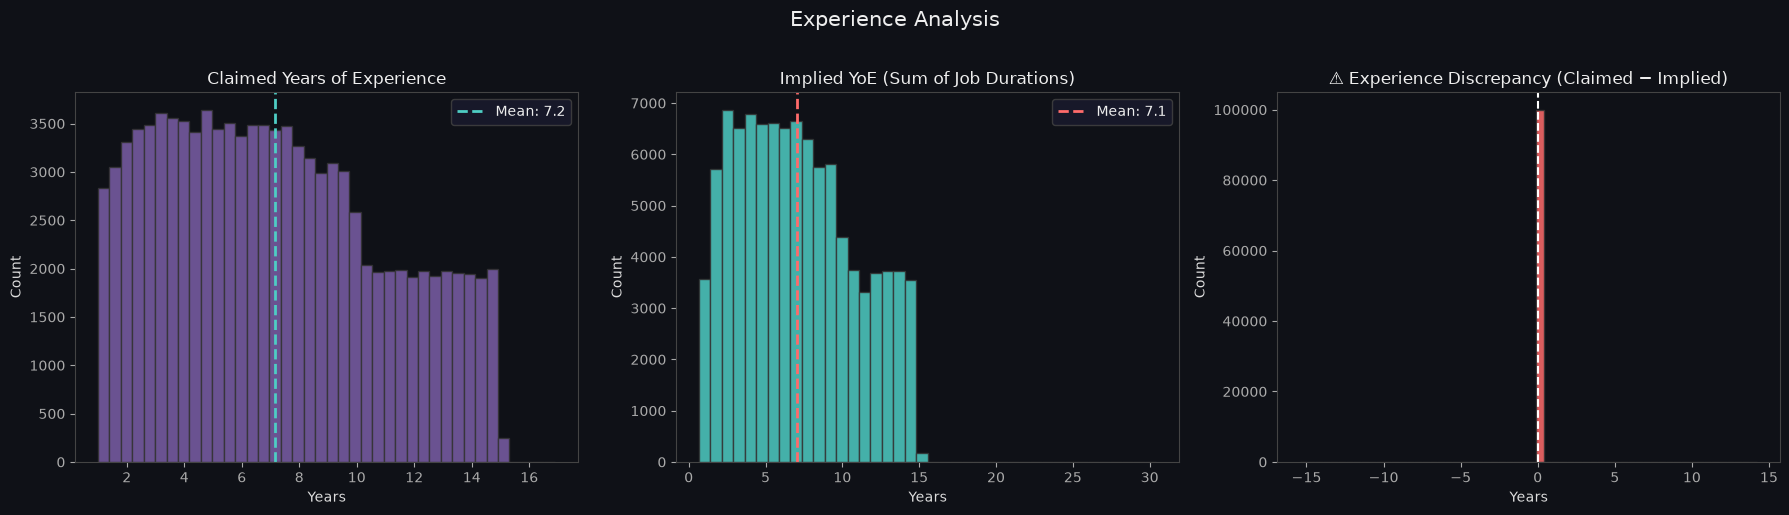


Experience Statistics:
       years_of_experience  implied_exp_years  exp_discrepancy
count            100000.00          100000.00        100000.00
mean                  7.17               7.06             0.10
std                   3.82               3.78             0.22
min                   1.00               0.67           -15.42
25%                   3.90               3.83             0.05
50%                   6.80               6.75             0.10
75%                   9.90               9.83             0.15
max                  16.90              30.42            14.23

⚠️  Candidates with |discrepancy| > 5 years: 39 (0.0%)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Claimed YoE
ax = axes[0]
ax.hist(df["years_of_experience"].dropna(), bins=40, color=ACCENT, edgecolor="#333", alpha=0.85)
ax.set_title("Claimed Years of Experience", fontsize=12)
ax.set_xlabel("Years"); ax.set_ylabel("Count")
ax.axvline(df["years_of_experience"].mean(), color=GOOD_CLR, lw=2, linestyle="--",
           label=f"Mean: {df['years_of_experience'].mean():.1f}")
ax.legend()

# Implied YoE from career history
ax = axes[1]
ax.hist(df["implied_exp_years"].dropna(), bins=40, color="#4ECDC4", edgecolor="#333", alpha=0.85)
ax.set_title("Implied YoE (Sum of Job Durations)", fontsize=12)
ax.set_xlabel("Years"); ax.set_ylabel("Count")
ax.axvline(df["implied_exp_years"].mean(), color=WARN_CLR, lw=2, linestyle="--",
           label=f"Mean: {df['implied_exp_years'].mean():.1f}")
ax.legend()

# Discrepancy: Claimed vs Implied
df["exp_discrepancy"] = df["years_of_experience"] - df["implied_exp_years"]
ax = axes[2]
ax.hist(df["exp_discrepancy"].dropna(), bins=60, color=WARN_CLR, edgecolor="#333", alpha=0.85)
ax.set_title("⚠️ Experience Discrepancy (Claimed − Implied)", fontsize=12)
ax.set_xlabel("Years"); ax.set_ylabel("Count")
ax.axvline(0, color="#fff", lw=1.5, linestyle="--")

plt.suptitle("Experience Analysis", fontsize=15, y=1.02, color="#eee")
plt.tight_layout()
plt.savefig("experience_distribution.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

print(f"\nExperience Statistics:")
print(df[["years_of_experience","implied_exp_years","exp_discrepancy"]].describe().round(2))

# High discrepancy candidates
big_disc = df[df["exp_discrepancy"].abs() > 5]
print(f"\n⚠️  Candidates with |discrepancy| > 5 years: {len(big_disc)} ({len(big_disc)/len(df)*100:.1f}%)")


## 6. Location Distribution

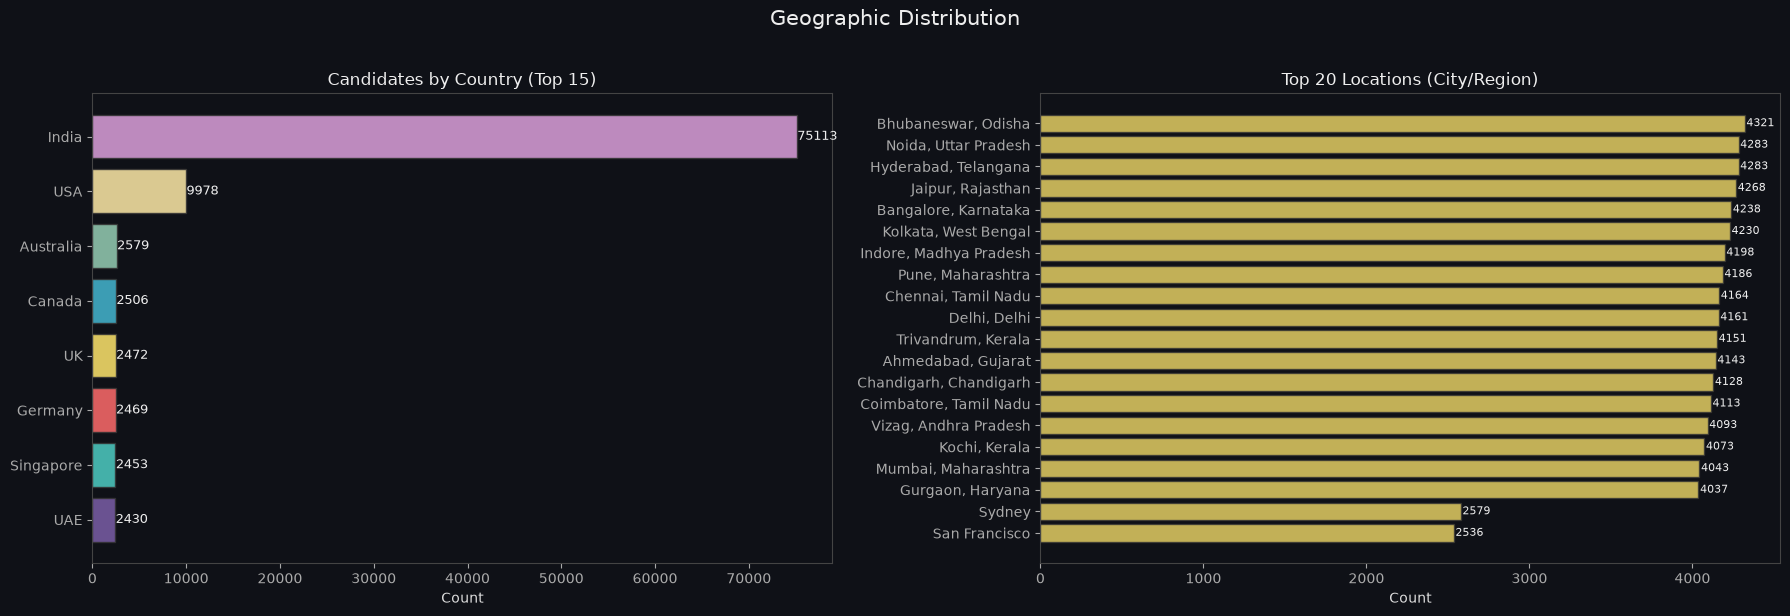

Country distribution:
country
India        75113
USA           9978
Australia     2579
Canada        2506
UK            2472
Germany       2469
Singapore     2453
UAE           2430
Name: count, dtype: int64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Country distribution
country_counts = df["country"].value_counts().head(15)
ax = axes[0]
bars = ax.barh(country_counts.index[::-1], country_counts.values[::-1],
               color=PALETTE[:len(country_counts)], edgecolor="#333", alpha=0.85)
ax.set_title("Candidates by Country (Top 15)", fontsize=12)
ax.set_xlabel("Count")
for bar, val in zip(bars, country_counts.values[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)

# City/Location distribution (Top 20)
loc_counts = df["location"].value_counts().head(20)
ax = axes[1]
bars = ax.barh(loc_counts.index[::-1], loc_counts.values[::-1],
               color=PALETTE[3], edgecolor="#333", alpha=0.75)
ax.set_title("Top 20 Locations (City/Region)", fontsize=12)
ax.set_xlabel("Count")
for bar, val in zip(bars, loc_counts.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=8)

plt.suptitle("Geographic Distribution", fontsize=15, y=1.02, color="#eee")
plt.tight_layout()
plt.savefig("location_distribution.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

print("Country distribution:")
print(df["country"].value_counts().head(20))


## 7. Skills Distribution

Total skill entries    : 960,302
Unique skill names     : 133


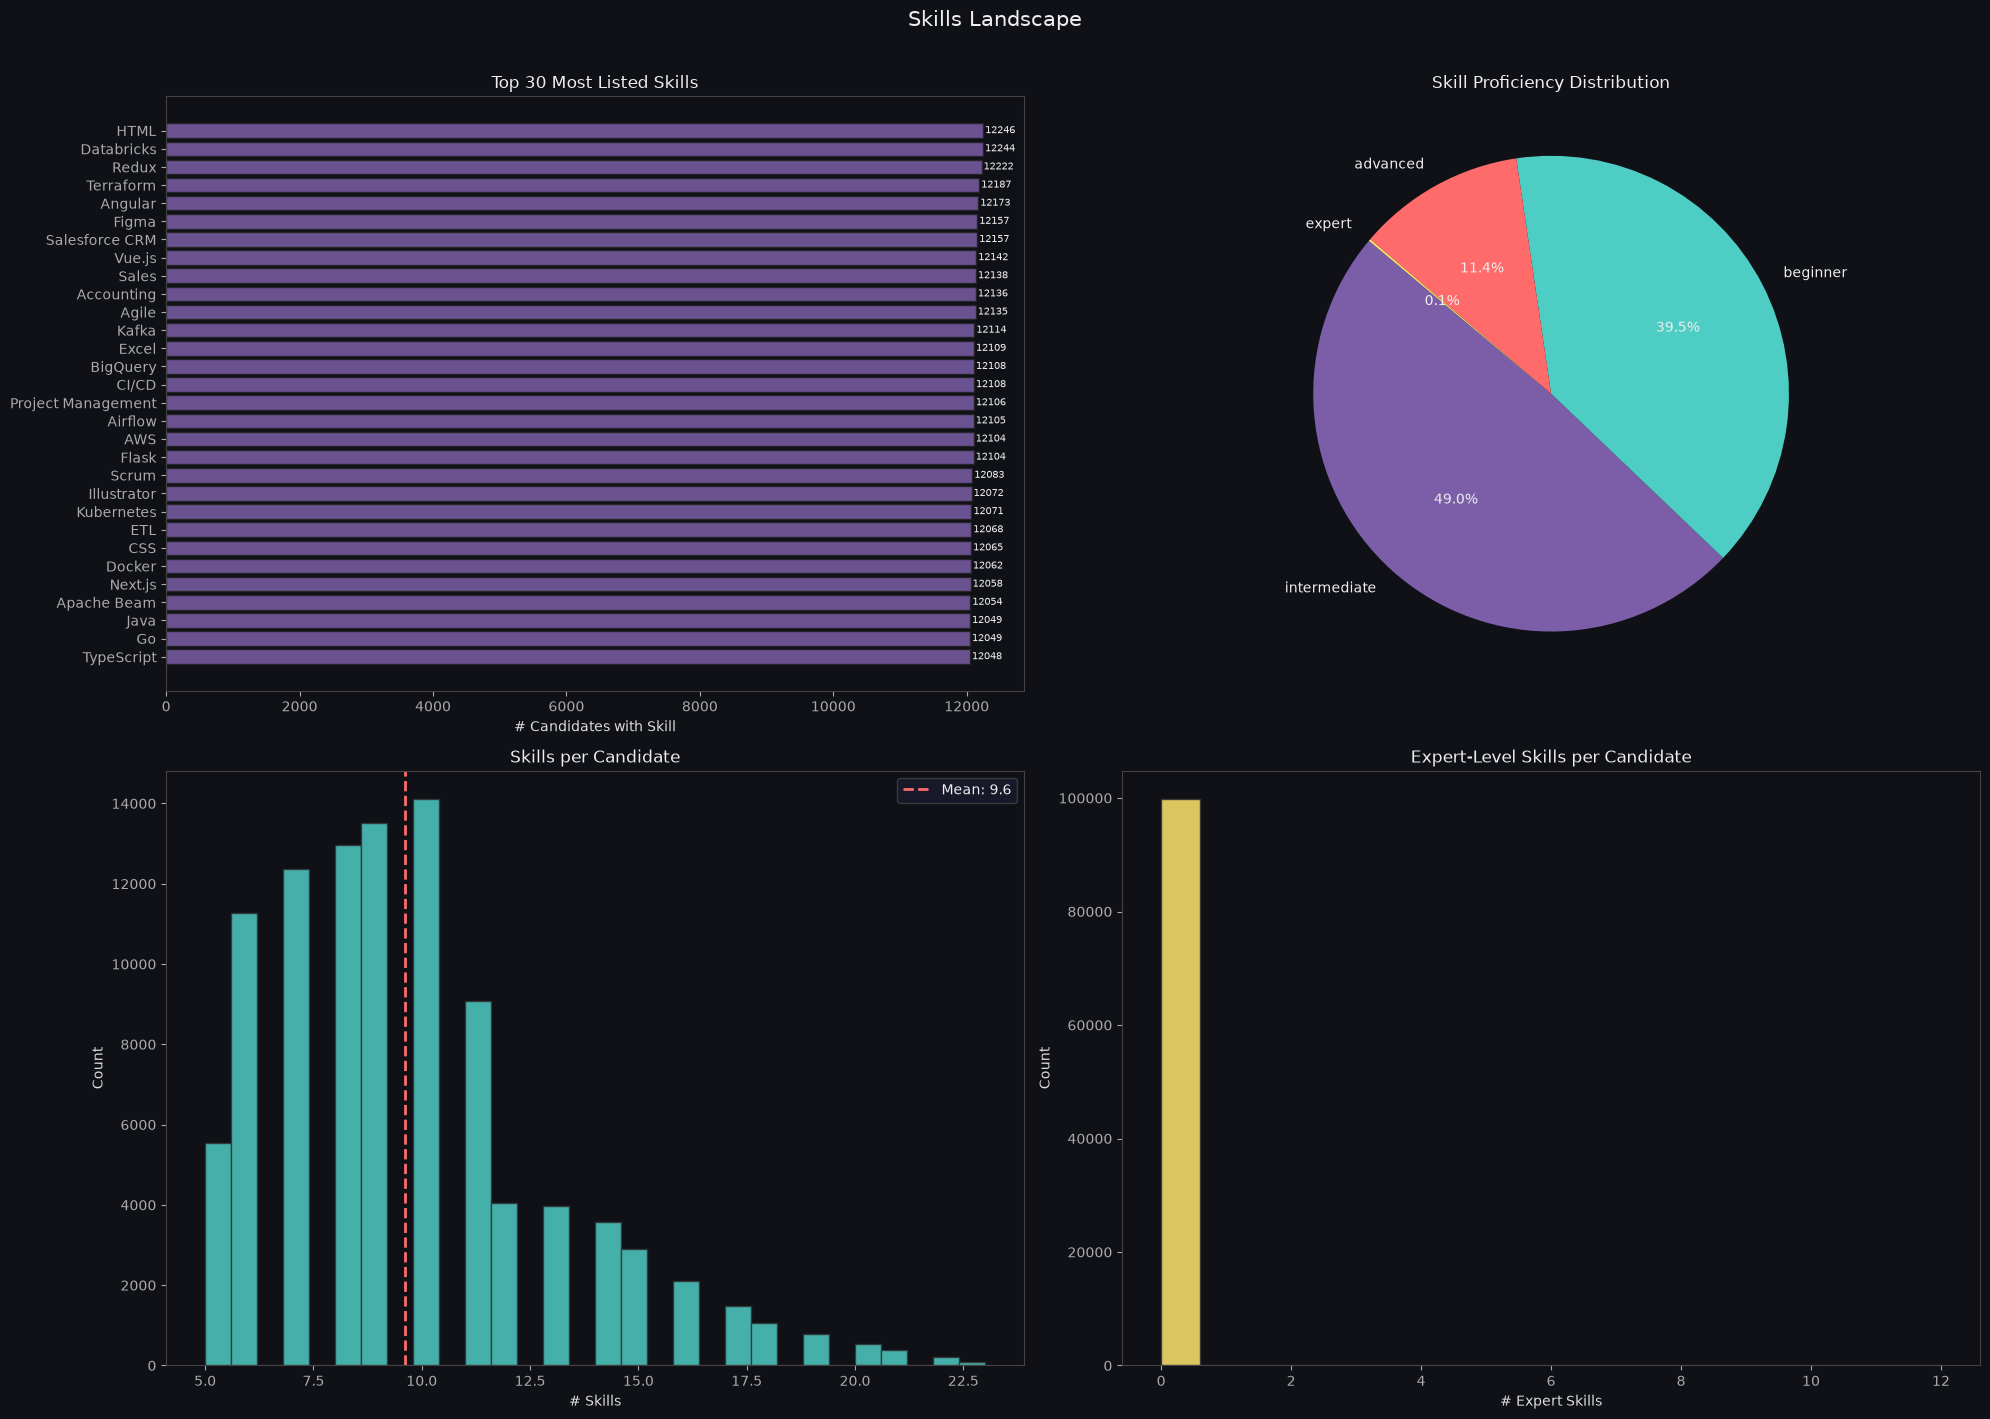


Skills per candidate: mean=9.6, median=9, max=23
Expert skills per candidate: mean=0.01


In [9]:
# Aggregate all skills across all candidates
all_skills = []
for c in candidates:
    for s in c.get("skills", []):
        all_skills.append({
            "name":         s.get("name",""),
            "proficiency":  s.get("proficiency",""),
            "endorsements": s.get("endorsements", 0),
            "duration_months": s.get("duration_months", 0),
        })

skills_df = pd.DataFrame(all_skills)
print(f"Total skill entries    : {len(skills_df):,}")
print(f"Unique skill names     : {skills_df['name'].nunique():,}")

# Top 30 most common skills
top_skills = skills_df["name"].value_counts().head(30)

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Top 30 skills
ax = axes[0, 0]
bars = ax.barh(top_skills.index[::-1], top_skills.values[::-1],
               color=ACCENT, edgecolor="#222", alpha=0.85)
ax.set_title("Top 30 Most Listed Skills", fontsize=12)
ax.set_xlabel("# Candidates with Skill")
for bar, val in zip(bars, top_skills.values[::-1]):
    ax.text(bar.get_width()+30, bar.get_y()+bar.get_height()/2, str(val),
            va="center", fontsize=7)

# Proficiency breakdown
ax = axes[0, 1]
prof_counts = skills_df["proficiency"].value_counts()
wedge_colors = ["#7B5EA7","#4ECDC4","#FF6B6B","#FFE66D"]
wedges, texts, autotexts = ax.pie(prof_counts.values, labels=prof_counts.index,
                                   autopct="%1.1f%%", colors=wedge_colors,
                                   startangle=140, textprops={"color":"#eee"})
for at in autotexts: at.set_fontsize(10)
ax.set_title("Skill Proficiency Distribution", fontsize=12)

# Skills per candidate
ax = axes[1, 0]
ax.hist(df["n_skills"], bins=30, color="#4ECDC4", edgecolor="#333", alpha=0.85)
ax.set_title("Skills per Candidate", fontsize=12)
ax.set_xlabel("# Skills"); ax.set_ylabel("Count")
ax.axvline(df["n_skills"].mean(), color=WARN_CLR, lw=2, linestyle="--",
           label=f"Mean: {df['n_skills'].mean():.1f}")
ax.legend()

# Expert skill count distribution
ax = axes[1, 1]
ax.hist(df["n_expert_skills"], bins=20, color="#FFE66D", edgecolor="#333", alpha=0.85)
ax.set_title("Expert-Level Skills per Candidate", fontsize=12)
ax.set_xlabel("# Expert Skills"); ax.set_ylabel("Count")

plt.suptitle("Skills Landscape", fontsize=15, y=1.01, color="#eee")
plt.tight_layout()
plt.savefig("skills_distribution.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

print(f"\nSkills per candidate: mean={df['n_skills'].mean():.1f}, median={df['n_skills'].median():.0f}, max={df['n_skills'].max()}")
print(f"Expert skills per candidate: mean={df['n_expert_skills'].mean():.2f}")


## 8. AI/ML Core Skills Analysis (Job-Relevant)

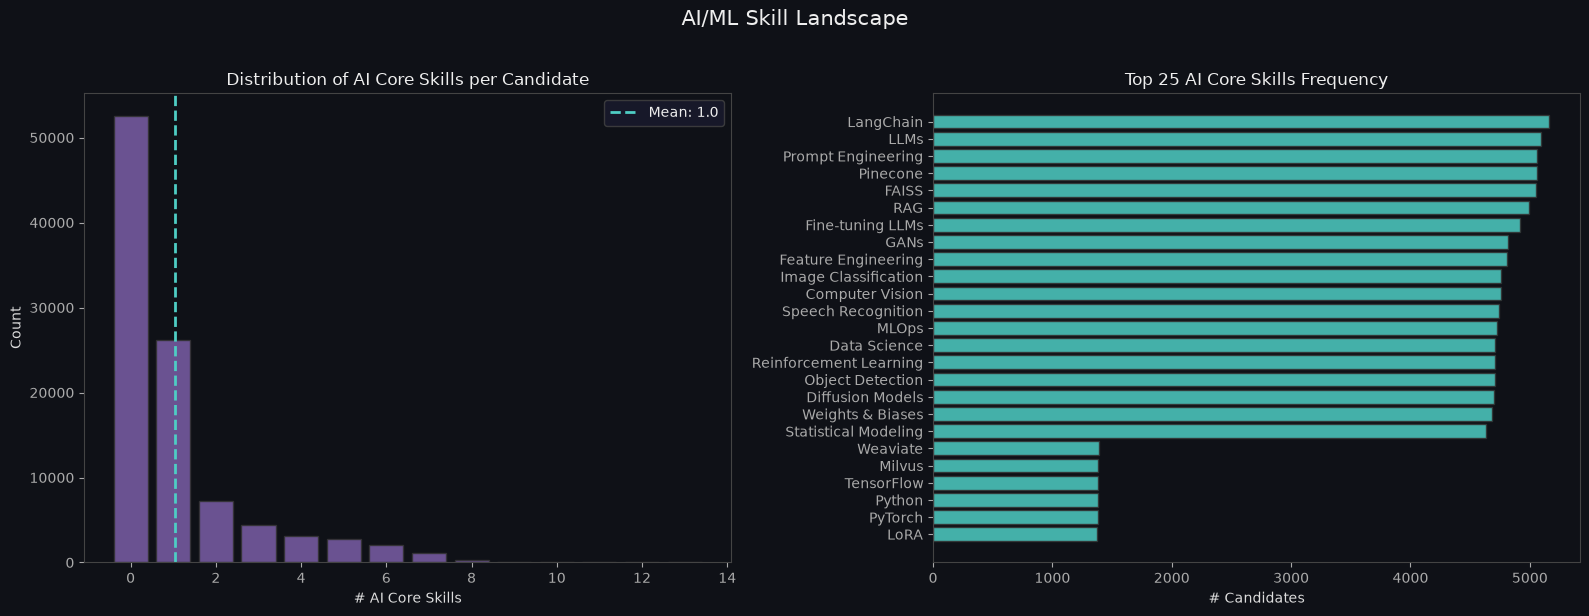


Candidates with 0 AI skills  : 52,580 (52.6%)
Candidates with 5+ AI skills : 6,381 (6.4%)
Candidates with 10+ AI skills: 59 (0.1%)


In [10]:
# Core skills for Senior AI Engineer role
AI_CORE_SKILLS = {
    "Python", "Machine Learning", "Deep Learning", "NLP", "LLMs",
    "Fine-tuning LLMs", "PyTorch", "TensorFlow", "Transformers",
    "RAG", "Vector Databases", "MLOps", "Hugging Face",
    "Computer Vision", "Reinforcement Learning", "Prompt Engineering",
    "LangChain", "OpenAI API", "Data Science", "Statistics",
    "Scikit-learn", "Model Deployment", "ONNX", "LoRA",
    "Milvus", "Pinecone", "Weaviate", "FAISS",
    "GANs", "Diffusion Models", "Speech Recognition",
    "Image Classification", "Object Detection",
    "Weights & Biases", "DVC", "Feature Engineering",
    "Statistical Modeling", "A/B Testing"
}

def count_ai_skills(c):
    skill_names = {s["name"] for s in c.get("skills", [])}
    return len(skill_names & AI_CORE_SKILLS)

def get_ai_skills(c):
    skill_names = {s["name"] for s in c.get("skills", [])}
    return skill_names & AI_CORE_SKILLS

df["n_ai_skills"] = [count_ai_skills(c) for c in candidates]

# Distribution of AI skill counts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ai_skill_counts = df["n_ai_skills"].value_counts().sort_index()
bars = ax.bar(ai_skill_counts.index, ai_skill_counts.values,
              color=ACCENT, edgecolor="#333", alpha=0.85)
ax.set_title("Distribution of AI Core Skills per Candidate", fontsize=12)
ax.set_xlabel("# AI Core Skills"); ax.set_ylabel("Count")
ax.axvline(df["n_ai_skills"].mean(), color=GOOD_CLR, lw=2, linestyle="--",
           label=f"Mean: {df['n_ai_skills'].mean():.1f}")
ax.legend()

# Top 25 AI skills frequency
ai_skill_freq = Counter()
for c in candidates:
    ai_skills_found = get_ai_skills(c)
    ai_skill_freq.update(ai_skills_found)

top_ai = pd.Series(ai_skill_freq).sort_values(ascending=False).head(25)
ax = axes[1]
bars = ax.barh(top_ai.index[::-1], top_ai.values[::-1],
               color=GOOD_CLR, edgecolor="#333", alpha=0.85)
ax.set_title("Top 25 AI Core Skills Frequency", fontsize=12)
ax.set_xlabel("# Candidates")

plt.suptitle("AI/ML Skill Landscape", fontsize=15, y=1.02, color="#eee")
plt.tight_layout()
plt.savefig("ai_skills.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

print(f"\nCandidates with 0 AI skills  : {(df['n_ai_skills']==0).sum():,} ({(df['n_ai_skills']==0).mean()*100:.1f}%)")
print(f"Candidates with 5+ AI skills : {(df['n_ai_skills']>=5).sum():,} ({(df['n_ai_skills']>=5).mean()*100:.1f}%)")
print(f"Candidates with 10+ AI skills: {(df['n_ai_skills']>=10).sum():,} ({(df['n_ai_skills']>=10).mean()*100:.1f}%)")


## 9. Education Distribution

Total education records: 139,778
Candidates with 0 edu  : 0


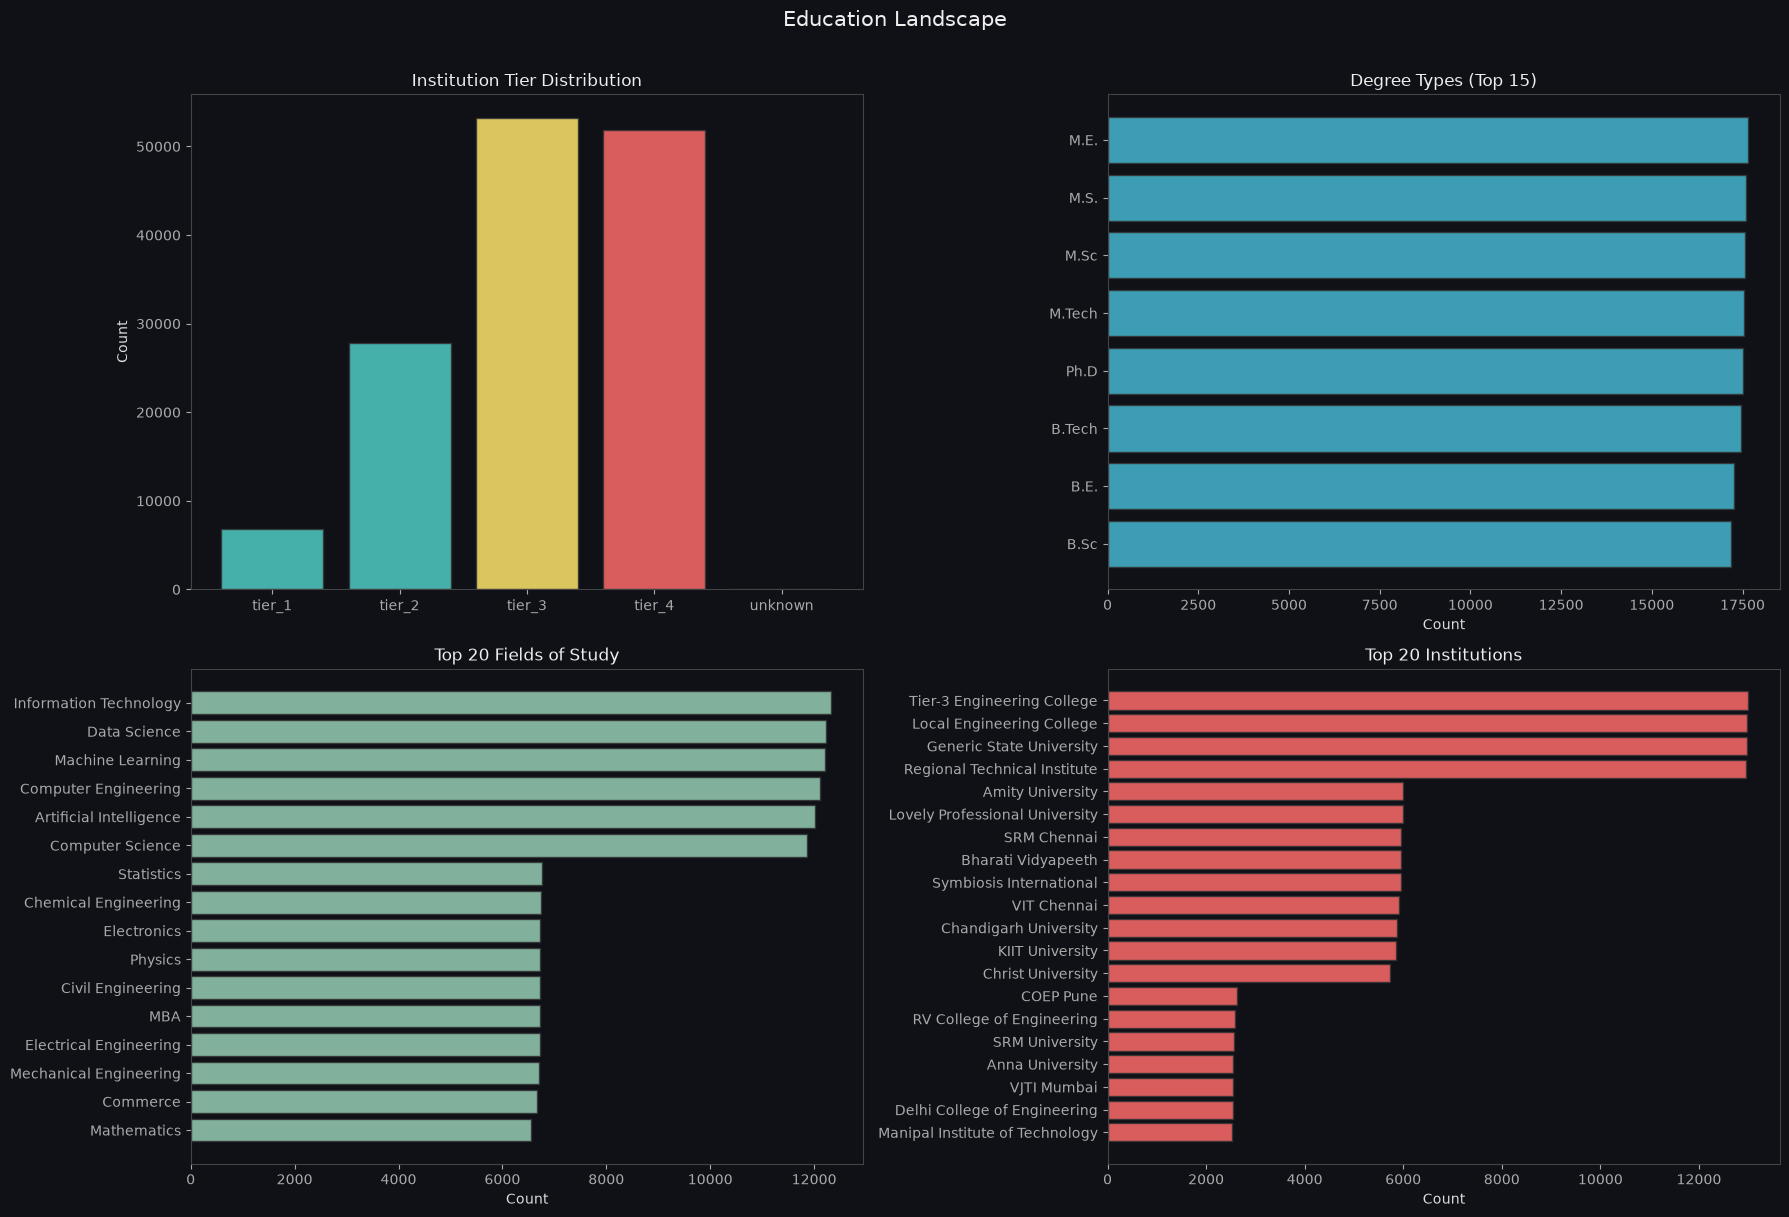


⚠️  Impossible education timelines: 0 records


⚠️  Overlapping education periods   : 13808


In [11]:
# Collect all education records
all_edu = []
for c in candidates:
    for e in c.get("education", []):
        all_edu.append({
            "cid":           c["candidate_id"],
            "institution":   e.get("institution",""),
            "degree":        e.get("degree",""),
            "field":         e.get("field_of_study",""),
            "start_year":    e.get("start_year"),
            "end_year":      e.get("end_year"),
            "tier":          e.get("tier","unknown"),
        })

edu_df = pd.DataFrame(all_edu)
print(f"Total education records: {len(edu_df):,}")
print(f"Candidates with 0 edu  : {(df['n_edu']==0).sum():,}")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Tier distribution
ax = axes[0, 0]
tier_order = ["tier_1","tier_2","tier_3","tier_4","unknown"]
tier_colors = [GOOD_CLR, "#4ECDC4", "#FFE66D", WARN_CLR, "#888"]
tier_counts = edu_df["tier"].value_counts().reindex(tier_order, fill_value=0)
ax.bar(tier_counts.index, tier_counts.values, color=tier_colors, edgecolor="#333", alpha=0.85)
ax.set_title("Institution Tier Distribution", fontsize=12)
ax.set_ylabel("Count")

# Degree type
ax = axes[0, 1]
degree_counts = edu_df["degree"].value_counts().head(15)
bars = ax.barh(degree_counts.index[::-1], degree_counts.values[::-1],
               color=PALETTE[4], edgecolor="#333", alpha=0.85)
ax.set_title("Degree Types (Top 15)", fontsize=12)
ax.set_xlabel("Count")

# Field of Study
ax = axes[1, 0]
field_counts = edu_df["field"].value_counts().head(20)
bars = ax.barh(field_counts.index[::-1], field_counts.values[::-1],
               color=PALETTE[5], edgecolor="#333", alpha=0.85)
ax.set_title("Top 20 Fields of Study", fontsize=12)
ax.set_xlabel("Count")

# Top institutions
ax = axes[1, 1]
inst_counts = edu_df["institution"].value_counts().head(20)
bars = ax.barh(inst_counts.index[::-1], inst_counts.values[::-1],
               color=PALETTE[2], edgecolor="#333", alpha=0.85)
ax.set_title("Top 20 Institutions", fontsize=12)
ax.set_xlabel("Count")

plt.suptitle("Education Landscape", fontsize=15, y=1.01, color="#eee")
plt.tight_layout()
plt.savefig("education_distribution.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

# Impossible education timelines
edu_df["duration"] = edu_df["end_year"] - edu_df["start_year"]
impossible_edu = edu_df[(edu_df["duration"] < 0) | (edu_df["duration"] > 12) | (edu_df["end_year"] > 2030)]
print(f"\n⚠️  Impossible education timelines: {len(impossible_edu)} records")

# Overlapping degrees (same person, overlapping years)
overlap_edu = 0
for cid, grp in edu_df.groupby("cid"):
    records = grp.sort_values("start_year")
    for i in range(len(records)-1):
        r1 = records.iloc[i]
        r2 = records.iloc[i+1]
        if pd.notna(r1.end_year) and pd.notna(r2.start_year):
            if r2.start_year < r1.end_year:
                overlap_edu += 1
print(f"⚠️  Overlapping education periods   : {overlap_edu}")


## 10. Company Distribution

Total job records     : 300,171
Unique companies      : 63


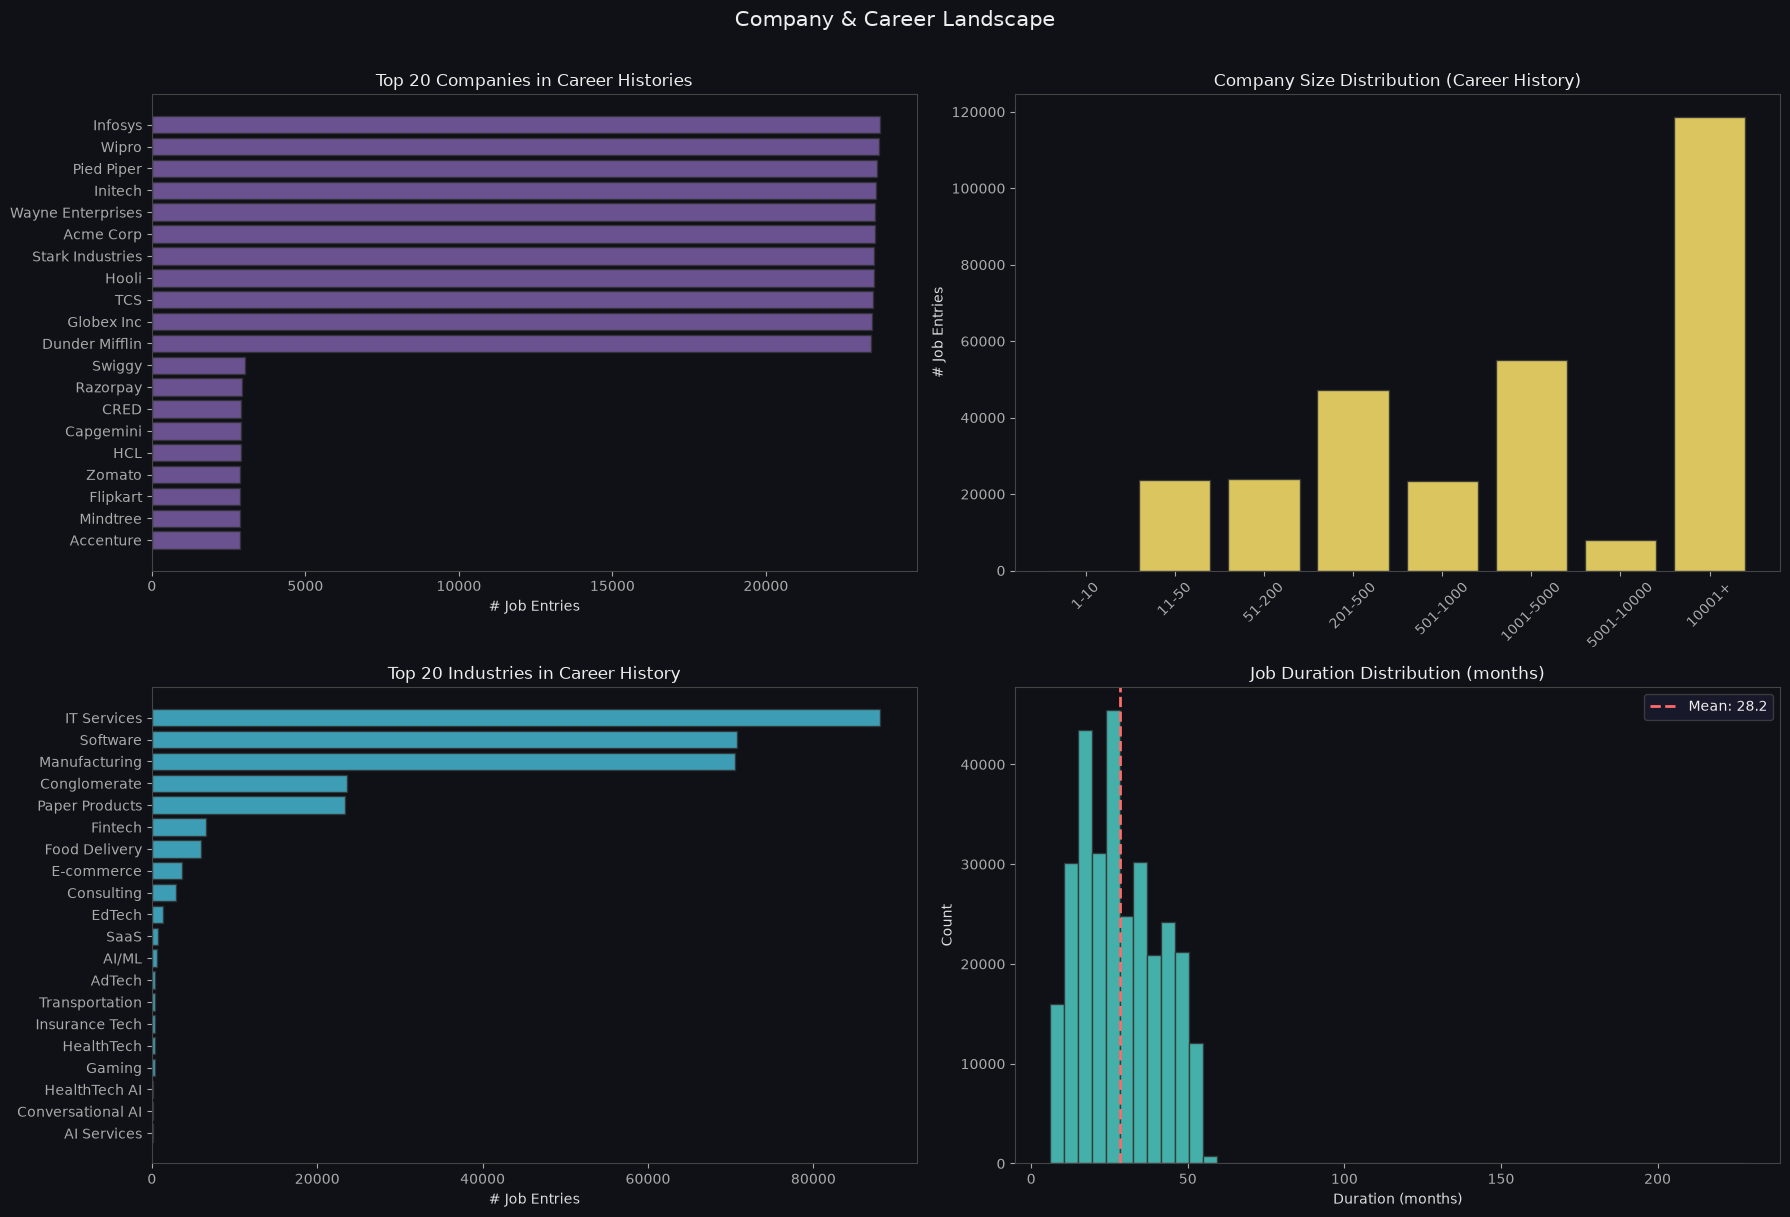


Job entries per candidate: mean=3.00, max=9
Very short jobs (<3 months): 0 (0.0%)
Current title distribution:
current_title
Business Analyst        5833
HR Manager              5830
Mechanical Engineer     5791
Accountant              5764
Project Manager         5754
Customer Support        5750
Operations Manager      5744
Content Writer          5727
Sales Executive         5713
Civil Engineer          5702
Graphic Designer        5689
Marketing Manager       5524
Software Engineer       3450
Full Stack Developer    2873
Cloud Engineer          2836
Name: count, dtype: int64


In [12]:
# All companies across career histories
all_companies = []
for c in candidates:
    for job in c.get("career_history", []):
        all_companies.append({
            "cid":          c["candidate_id"],
            "company":      job.get("company",""),
            "title":        job.get("title",""),
            "duration":     job.get("duration_months", 0),
            "company_size": job.get("company_size",""),
            "industry":     job.get("industry",""),
            "is_current":   job.get("is_current", False),
        })

jobs_df = pd.DataFrame(all_companies)
print(f"Total job records     : {len(jobs_df):,}")
print(f"Unique companies      : {jobs_df['company'].nunique():,}")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Top companies
ax = axes[0, 0]
co_counts = jobs_df["company"].value_counts().head(20)
bars = ax.barh(co_counts.index[::-1], co_counts.values[::-1],
               color=ACCENT, edgecolor="#333", alpha=0.85)
ax.set_title("Top 20 Companies in Career Histories", fontsize=12)
ax.set_xlabel("# Job Entries")

# Company size distribution
ax = axes[0, 1]
size_order = ["1-10","11-50","51-200","201-500","501-1000","1001-5000","5001-10000","10001+"]
size_counts = jobs_df["company_size"].value_counts().reindex(size_order, fill_value=0)
ax.bar(size_counts.index, size_counts.values, color=PALETTE[3], edgecolor="#333", alpha=0.85)
ax.set_title("Company Size Distribution (Career History)", fontsize=12)
ax.set_ylabel("# Job Entries")
ax.tick_params(axis="x", rotation=45)

# Industry distribution
ax = axes[1, 0]
ind_counts = jobs_df["industry"].value_counts().head(20)
bars = ax.barh(ind_counts.index[::-1], ind_counts.values[::-1],
               color=PALETTE[4], edgecolor="#333", alpha=0.85)
ax.set_title("Top 20 Industries in Career History", fontsize=12)
ax.set_xlabel("# Job Entries")

# Job duration distribution
ax = axes[1, 1]
ax.hist(jobs_df["duration"].dropna(), bins=50, color=GOOD_CLR, edgecolor="#333", alpha=0.85)
ax.set_title("Job Duration Distribution (months)", fontsize=12)
ax.set_xlabel("Duration (months)"); ax.set_ylabel("Count")
ax.axvline(jobs_df["duration"].mean(), color=WARN_CLR, lw=2, linestyle="--",
           label=f"Mean: {jobs_df['duration'].mean():.1f}")
ax.legend()

plt.suptitle("Company & Career Landscape", fontsize=15, y=1.01, color="#eee")
plt.tight_layout()
plt.savefig("company_distribution.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

print(f"\nJob entries per candidate: mean={df['n_jobs'].mean():.2f}, max={df['n_jobs'].max()}")
print(f"Very short jobs (<3 months): {(jobs_df['duration'] < 3).sum():,} ({(jobs_df['duration']<3).mean()*100:.1f}%)")
print(f"Current title distribution:")
print(df["current_title"].value_counts().head(15))


## 11. Behavioral Signal Analysis

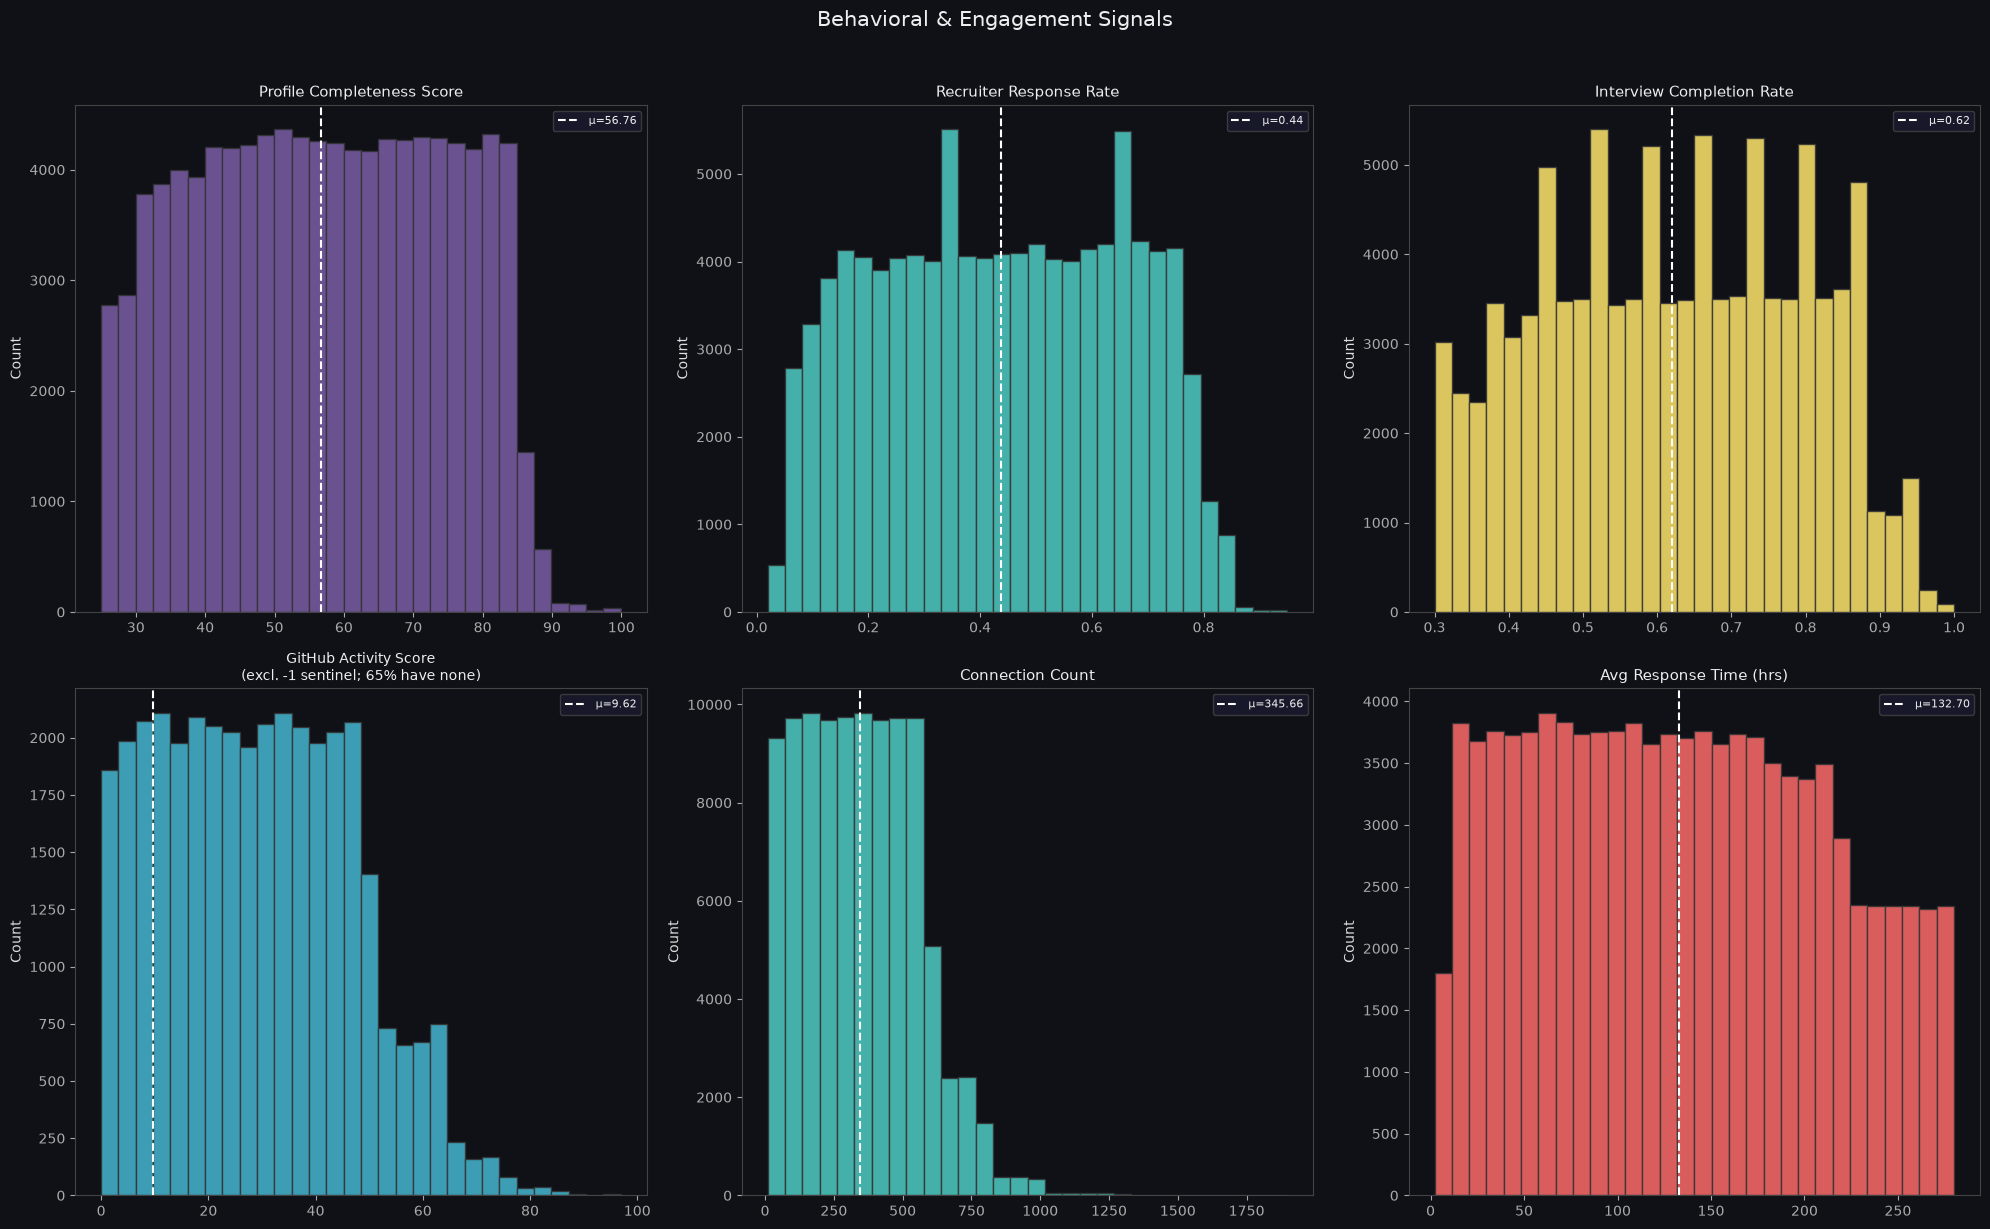


Behavioral Signal Summary:
       profile_completeness  recruiter_response_rate  \
count            100000.000               100000.000   
mean                 56.758                    0.437   
std                  17.274                    0.214   
min                  25.000                    0.020   
25%                  42.200                    0.250   
50%                  56.800                    0.440   
75%                  71.600                    0.620   
max                  99.900                    0.950   

       interview_completion_rate  github_activity_score  connection_count  \
count                 100000.000             100000.000        100000.000   
mean                       0.620                  9.619           345.665   
std                        0.171                 17.761           208.146   
min                        0.300                 -1.000            10.000   
25%                        0.480                 -1.000           174.000   
50%  

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

signal_fields = [
    ("profile_completeness",       "Profile Completeness Score", ACCENT),
    ("recruiter_response_rate",    "Recruiter Response Rate",    GOOD_CLR),
    ("interview_completion_rate",  "Interview Completion Rate",  PALETTE[3]),
    ("github_activity_score",      "GitHub Activity Score",      PALETTE[4]),
    ("connection_count",           "Connection Count",           PALETTE[1]),
    ("avg_response_time_hours",    "Avg Response Time (hrs)",    WARN_CLR),
]

for ax, (col, title, clr) in zip(axes.flatten(), signal_fields):
    data = df[col].dropna()
    # For github score remove -1 sentinel for histogram
    if col == "github_activity_score":
        data_plot = data[data >= 0]
        no_github_pct = (data == -1).mean() * 100
        ax.hist(data_plot, bins=30, color=clr, edgecolor="#333", alpha=0.85)
        ax.set_title(f"{title}\n(excl. -1 sentinel; {no_github_pct:.0f}% have none)", fontsize=10)
    else:
        ax.hist(data, bins=30, color=clr, edgecolor="#333", alpha=0.85)
        ax.set_title(title, fontsize=11)
    ax.set_ylabel("Count")
    ax.axvline(data.mean(), color="#fff", lw=1.5, linestyle="--",
               label=f"μ={data.mean():.2f}")
    ax.legend(fontsize=8)

plt.suptitle("Behavioral & Engagement Signals", fontsize=15, y=1.02, color="#eee")
plt.tight_layout()
plt.savefig("behavioral_signals.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

# Summary stats
print("\nBehavioral Signal Summary:")
sig_cols = ["profile_completeness","recruiter_response_rate","interview_completion_rate",
            "github_activity_score","connection_count","avg_response_time_hours",
            "saved_by_recruiters_30d","search_appearance_30d"]
print(df[sig_cols].describe().round(3))


## 12. Recruiter Engagement Signal Analysis

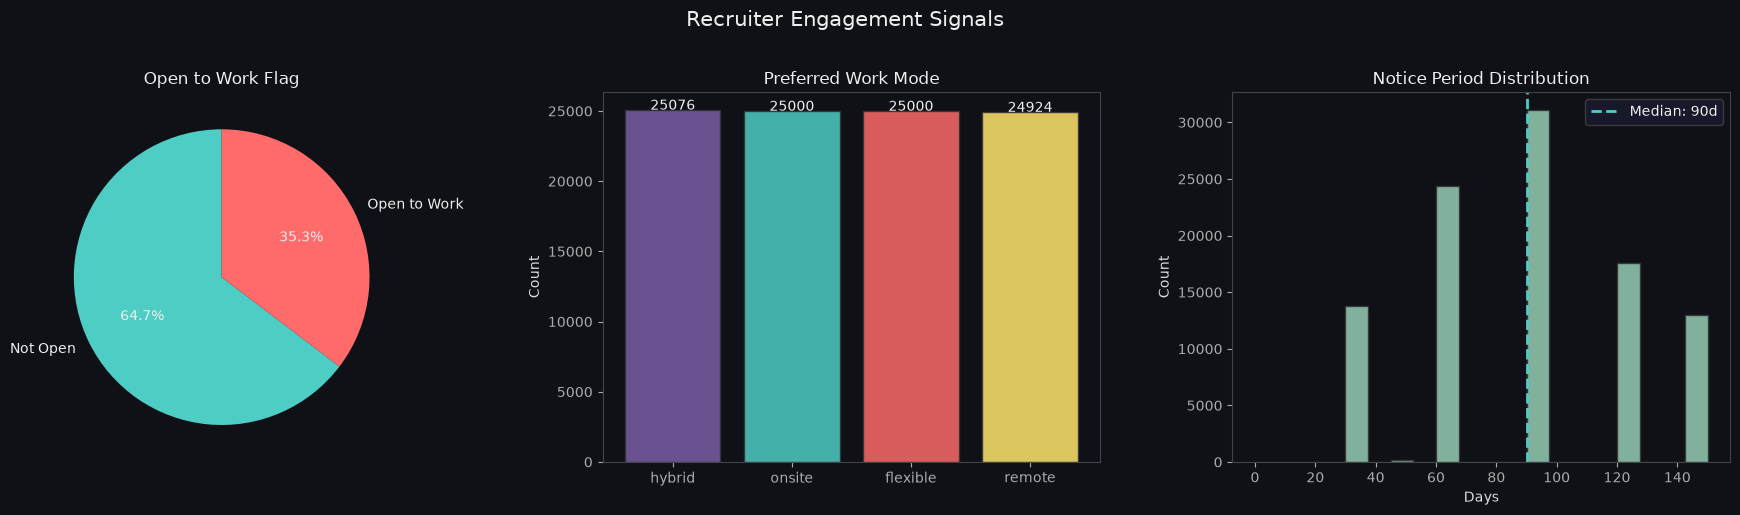

Verification Rates:
  verified_email    : 72.0%
  verified_phone    : 61.8%
  linkedin_connected: 36.0%
  willing_to_relocate: 28.8%

Offer acceptance rate (excl. -1): 47.5%
Candidates with no offer history (-1): 59,554

Salary Range (INR LPA):
       salary_min  salary_max
count   100000.00   100000.00
mean        12.17       19.84
std          5.56        8.32
min          3.00        6.00
25%          7.80       13.50
50%         11.90       19.40
75%         15.80       25.20
max         49.70       74.50


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Open to work
ax = axes[0]
otw = df["open_to_work"].value_counts()
wedges, texts, auts = ax.pie(otw.values, labels=["Open to Work" if v else "Not Open" for v in otw.index],
                             autopct="%1.1f%%", colors=[GOOD_CLR, WARN_CLR],
                             startangle=90, textprops={"color":"#eee"})
ax.set_title("Open to Work Flag", fontsize=12)

# Work mode preference
ax = axes[1]
wm = df["preferred_work_mode"].value_counts()
bars = ax.bar(wm.index, wm.values, color=PALETTE[:len(wm)], edgecolor="#333", alpha=0.85)
ax.set_title("Preferred Work Mode", fontsize=12)
ax.set_ylabel("Count")
for bar, val in zip(bars, wm.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            str(val), ha="center", fontsize=10)

# Notice period distribution
ax = axes[2]
ax.hist(df["notice_period_days"].dropna(), bins=20, color=PALETTE[5], edgecolor="#333", alpha=0.85)
ax.set_title("Notice Period Distribution", fontsize=12)
ax.set_xlabel("Days"); ax.set_ylabel("Count")
ax.axvline(df["notice_period_days"].median(), color=GOOD_CLR, lw=2, linestyle="--",
           label=f"Median: {df['notice_period_days'].median():.0f}d")
ax.legend()

plt.suptitle("Recruiter Engagement Signals", fontsize=15, y=1.02, color="#eee")
plt.tight_layout()
plt.savefig("recruiter_signals.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

# Verification rates
print("Verification Rates:")
print(f"  verified_email    : {df['verified_email'].mean()*100:.1f}%")
print(f"  verified_phone    : {df['verified_phone'].mean()*100:.1f}%")
print(f"  linkedin_connected: {df['linkedin_connected'].mean()*100:.1f}%")
print(f"  willing_to_relocate: {df['willing_to_relocate'].mean()*100:.1f}%")
print(f"\nOffer acceptance rate (excl. -1): {df[df['offer_acceptance_rate']>=0]['offer_acceptance_rate'].mean()*100:.1f}%")
print(f"Candidates with no offer history (-1): {(df['offer_acceptance_rate']==-1).sum():,}")

# Salary distribution
print(f"\nSalary Range (INR LPA):")
print(df[["salary_min","salary_max"]].describe().round(2))


## 13. 🍯 Honeypot & Data Quality Forensics

Identifying suspicious patterns that indicate inflated, fake, or bot-generated profiles.


In [15]:
honeypot_flags = defaultdict(list)  # cid -> list of flag descriptions

for c in tqdm(candidates, desc="Honeypot scan"):
    cid    = c["candidate_id"]
    p      = c.get("profile", {})
    career = c.get("career_history", [])
    edu    = c.get("education", [])
    skills = c.get("skills", [])
    rs     = c.get("redrob_signals", {})

    claimed_yoe = p.get("years_of_experience", 0) or 0

    # ── 1. Overlapping job periods ────────────────────────────────────────
    jobs_sorted = sorted(
        [j for j in career if j.get("start_date") and j.get("end_date")],
        key=lambda j: j["start_date"]
    )
    for i in range(len(jobs_sorted)-1):
        j1_end   = jobs_sorted[i]["end_date"]
        j2_start = jobs_sorted[i+1]["start_date"]
        if j1_end and j2_start and j2_start < j1_end:
            overlap_months = (datetime.strptime(j1_end,"%Y-%m-%d") -
                              datetime.strptime(j2_start,"%Y-%m-%d")).days / 30
            if overlap_months > 3:   # allow up to 3 months grace
                honeypot_flags[cid].append(
                    f"OVERLAP_JOBS: {jobs_sorted[i]['company']} & {jobs_sorted[i+1]['company']} "
                    f"overlap {overlap_months:.0f} months"
                )

    # ── 2. Impossible experience (claimed > career span + 2 yrs) ─────────
    total_career_yrs = sum(j.get("duration_months",0) or 0 for j in career) / 12
    if claimed_yoe > total_career_yrs + 3:
        honeypot_flags[cid].append(
            f"INFLATED_YOE: claimed {claimed_yoe:.1f}y, career sum {total_career_yrs:.1f}y"
        )

    # ── 3. Skill duration > total career duration ─────────────────────────
    total_months = sum(j.get("duration_months",0) or 0 for j in career)
    for s in skills:
        sk_dur = s.get("duration_months", 0) or 0
        if sk_dur > total_months + 12:
            honeypot_flags[cid].append(
                f"SKILL_DURATION_OVERFLOW: '{s['name']}' {sk_dur}m > career {total_months}m"
            )

    # ── 4. Expert skill with 0 endorsements ──────────────────────────────
    zero_endorse_experts = [s["name"] for s in skills
                            if s.get("proficiency") == "expert" and s.get("endorsements",0) == 0]
    if zero_endorse_experts:
        honeypot_flags[cid].append(
            f"UNENDORSED_EXPERT: {zero_endorse_experts}"
        )

    # ── 5. Profile completeness mismatch ─────────────────────────────────
    pcs = rs.get("profile_completeness_score", 100)
    n_skills = len(skills)
    n_edu    = len(edu)
    if pcs > 90 and n_skills < 3 and n_edu == 0:
        honeypot_flags[cid].append(
            f"PCS_MISMATCH: completeness {pcs} but only {n_skills} skills, {n_edu} edu"
        )

    # ── 6. Impossible education: degree earned before role started ────────
    for e in edu:
        sy = e.get("start_year"); ey = e.get("end_year")
        if sy and ey:
            dur = ey - sy
            if dur < 0:
                honeypot_flags[cid].append(f"EDU_NEG_DURATION: {e['institution']} {sy}-{ey}")
            if dur > 12:
                honeypot_flags[cid].append(f"EDU_LONG_DURATION: {e['institution']} {dur}y")

    # ── 7. Salary max < min ───────────────────────────────────────────────
    sal = rs.get("expected_salary_range_inr_lpa", {}) or {}
    if sal.get("min") and sal.get("max") and sal["max"] < sal["min"]:
        honeypot_flags[cid].append(
            f"SALARY_INVERTED: min={sal['min']} > max={sal['max']}"
        )

    # ── 8. High assessment score but 0 endorsements on that skill ─────────
    assessment = rs.get("skill_assessment_scores", {}) or {}
    skill_endorse_map = {s["name"]: s.get("endorsements",0) for s in skills}
    for sk, score in assessment.items():
        if score > 85 and skill_endorse_map.get(sk, 0) == 0:
            honeypot_flags[cid].append(
                f"HIGH_SCORE_ZERO_ENDORSE: '{sk}' score={score:.0f}, endorsements=0"
            )

    # ── 9. Title/role mismatch (current title vs career) ─────────────────
    curr_title = p.get("current_title","").lower()
    career_titles = [j.get("title","").lower() for j in career if j.get("is_current")]
    if career_titles and curr_title not in career_titles:
        honeypot_flags[cid].append(
            f"TITLE_MISMATCH: profile='{curr_title}' vs career={career_titles}"
        )

    # ── 10. Implausibly high signup-to-active recency ─────────────────────
    signup = rs.get("signup_date"); active = rs.get("last_active_date")
    if signup and active and signup > active:
        honeypot_flags[cid].append(f"DATE_PARADOX: last_active {active} < signup {signup}")

    # ── 11. Ghost candidate: 0 views, 0 searches, 0 saved, lots of apps ──
    pv  = rs.get("profile_views_received_30d", 0) or 0
    sa  = rs.get("search_appearance_30d", 0) or 0
    sbr = rs.get("saved_by_recruiters_30d", 0) or 0
    apps= rs.get("applications_submitted_30d", 0) or 0
    if pv == 0 and sa == 0 and sbr == 0 and apps > 5:
        honeypot_flags[cid].append(
            f"GHOST_PROFILE: 0 views/searches/saves but {apps} applications"
        )

total_flagged = len(honeypot_flags)
total_flags   = sum(len(v) for v in honeypot_flags.values())
print(f"\n{'='*60}")
print(f"  Candidates with at least 1 honeypot flag : {total_flagged:,}  ({total_flagged/len(candidates)*100:.1f}%)")
print(f"  Total individual flags raised             : {total_flags:,}")
print(f"  Average flags per flagged candidate       : {total_flags/max(total_flagged,1):.2f}")
print(f"{'='*60}")


Honeypot scan:   0%|          | 0/100000 [00:00<?, ?it/s]

Honeypot scan:   9%|▉         | 8777/100000 [00:00<00:01, 87761.30it/s]

Honeypot scan:  18%|█▊        | 17729/100000 [00:00<00:00, 88793.59it/s]

Honeypot scan:  29%|██▉       | 29297/100000 [00:00<00:00, 101067.13it/s]

Honeypot scan:  41%|████      | 41063/100000 [00:00<00:00, 107613.95it/s]

...

Honeypot scan:  64%|██████▍   | 64036/100000 [00:00<00:00, 109656.38it/s]

Honeypot scan:  75%|███████▌  | 75036/100000 [00:01<00:00, 48213.42it/s] 

Honeypot scan:  87%|████████▋ | 87448/100000 [00:01<00:00, 60946.24it/s]

Honeypot scan: 100%|██████████| 100000/100000 [00:01<00:00, 76466.87it/s]


  Candidates with at least 1 honeypot flag : 32,171  (32.2%)
  Total individual flags raised             : 42,917
  Average flags per flagged candidate       : 1.33



Flag type breakdown:


,Flag Type,Count
2,SALARY_INVERTED,18865
0,SKILL_DURATION_OVERFLOW,16500
1,DATE_PARADOX,7496
3,INFLATED_YOE,25
4,UNENDORSED_EXPERT,24
5,HIGH_SCORE_ZERO_ENDORSE,7


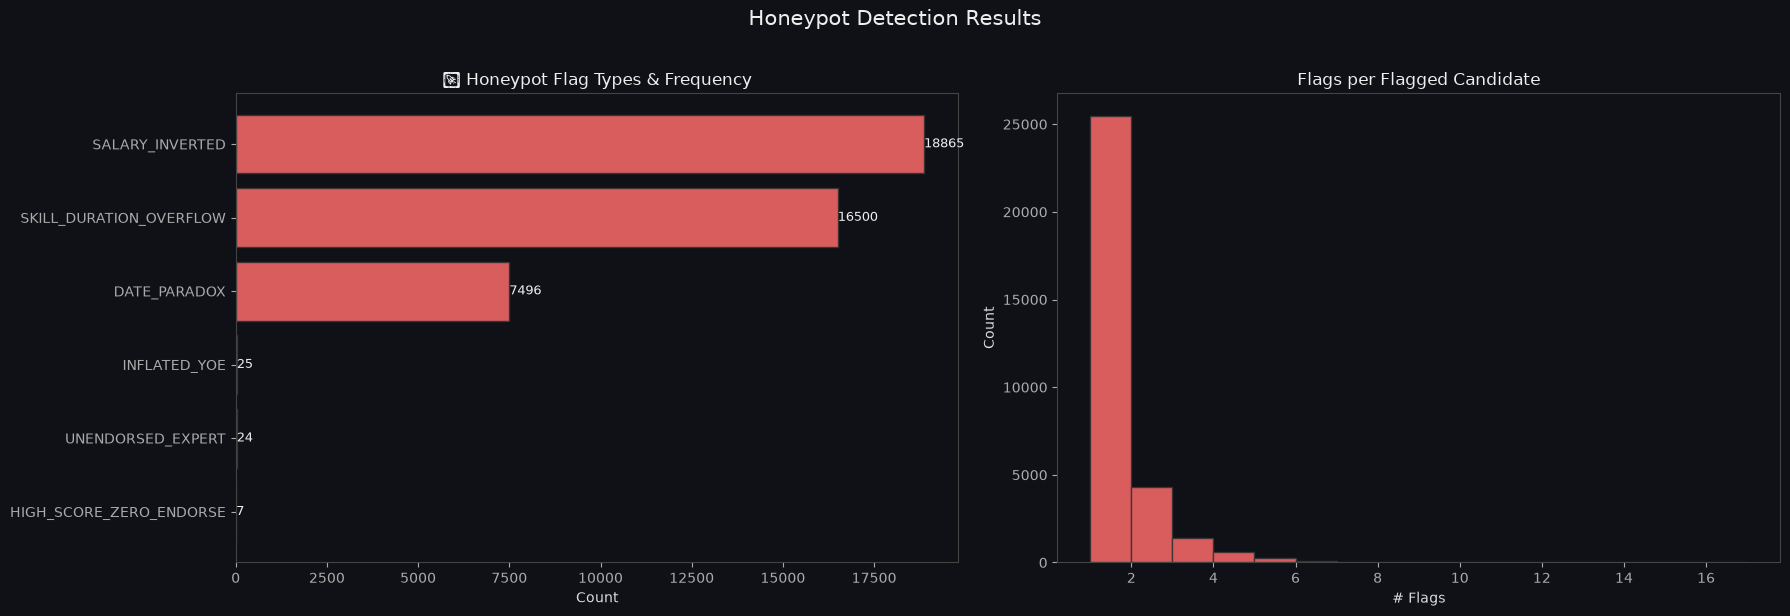


🚨 Top 10 Most Suspicious Candidates:

  CAND_0016062 (16 flags):
    ↳ SKILL_DURATION_OVERFLOW: 'Image Classification' 47m > career 13m
    ↳ SKILL_DURATION_OVERFLOW: 'RAG' 55m > career 13m
    ↳ SKILL_DURATION_OVERFLOW: 'Object Detection' 26m > career 13m
    ↳ SKILL_DURATION_OVERFLOW: 'Reinforcement Learning' 26m > career 13m
    ↳ SKILL_DURATION_OVERFLOW: 'YOLO' 27m > career 13m
    ↳ SKILL_DURATION_OVERFLOW: 'MLOps' 49m > career 13m
    ↳ SKILL_DURATION_OVERFLOW: 'LoRA' 58m > career 13m
    ↳ SKILL_DURATION_OVERFLOW: 'FAISS' 27m > career 13m
    ↳ SKILL_DURATION_OVERFLOW: 'Weaviate' 26m > career 13m
    ↳ SKILL_DURATION_OVERFLOW: 'NLP' 31m > career 13m
    ↳ SKILL_DURATION_OVERFLOW: 'BentoML' 31m > career 13m
    ↳ SKILL_DURATION_OVERFLOW: 'Time Series' 34m > career 13m
    ↳ SKILL_DURATION_OVERFLOW: 'Webpack' 28m > career 13m
    ↳ SKILL_DURATION_OVERFLOW: 'Milvus' 33m > career 13m
    ↳ SKILL_DURATION_OVERFLOW: 'Python' 36m > career 13m
    ↳ SALARY_INVERTED: min=19.8 > max=19.0

In [16]:
# Flag type breakdown
flag_type_counts = Counter()
for flags in honeypot_flags.values():
    for f in flags:
        flag_type = f.split(":")[0]
        flag_type_counts[flag_type] += 1

flag_df = pd.DataFrame(flag_type_counts.items(), columns=["Flag Type","Count"]).sort_values("Count", ascending=False)
print("\nFlag type breakdown:")
display(flag_df)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
bars = ax.barh(flag_df["Flag Type"][::-1], flag_df["Count"][::-1],
               color=WARN_CLR, edgecolor="#333", alpha=0.85)
ax.set_title("🚨 Honeypot Flag Types & Frequency", fontsize=12)
ax.set_xlabel("Count")
for bar, val in zip(bars, flag_df["Count"][::-1]):
    ax.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2, str(val),
            va="center", fontsize=9)

# Flags per candidate distribution
flags_per_cand = pd.Series({cid: len(flags) for cid, flags in honeypot_flags.items()})
ax = axes[1]
ax.hist(flags_per_cand, bins=range(1, flags_per_cand.max()+2), color=WARN_CLR, edgecolor="#333", alpha=0.85)
ax.set_title("Flags per Flagged Candidate", fontsize=12)
ax.set_xlabel("# Flags"); ax.set_ylabel("Count")

plt.suptitle("Honeypot Detection Results", fontsize=15, y=1.02, color="#eee")
plt.tight_layout()
plt.savefig("honeypot_analysis.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

# Worst offenders (multi-flag)
worst = sorted(honeypot_flags.items(), key=lambda x: len(x[1]), reverse=True)[:10]
print("\n🚨 Top 10 Most Suspicious Candidates:")
for cid, flags in worst:
    print(f"\n  {cid} ({len(flags)} flags):")
    for f in flags:
        print(f"    ↳ {f}")


## 14. Signal Correlation Heatmap

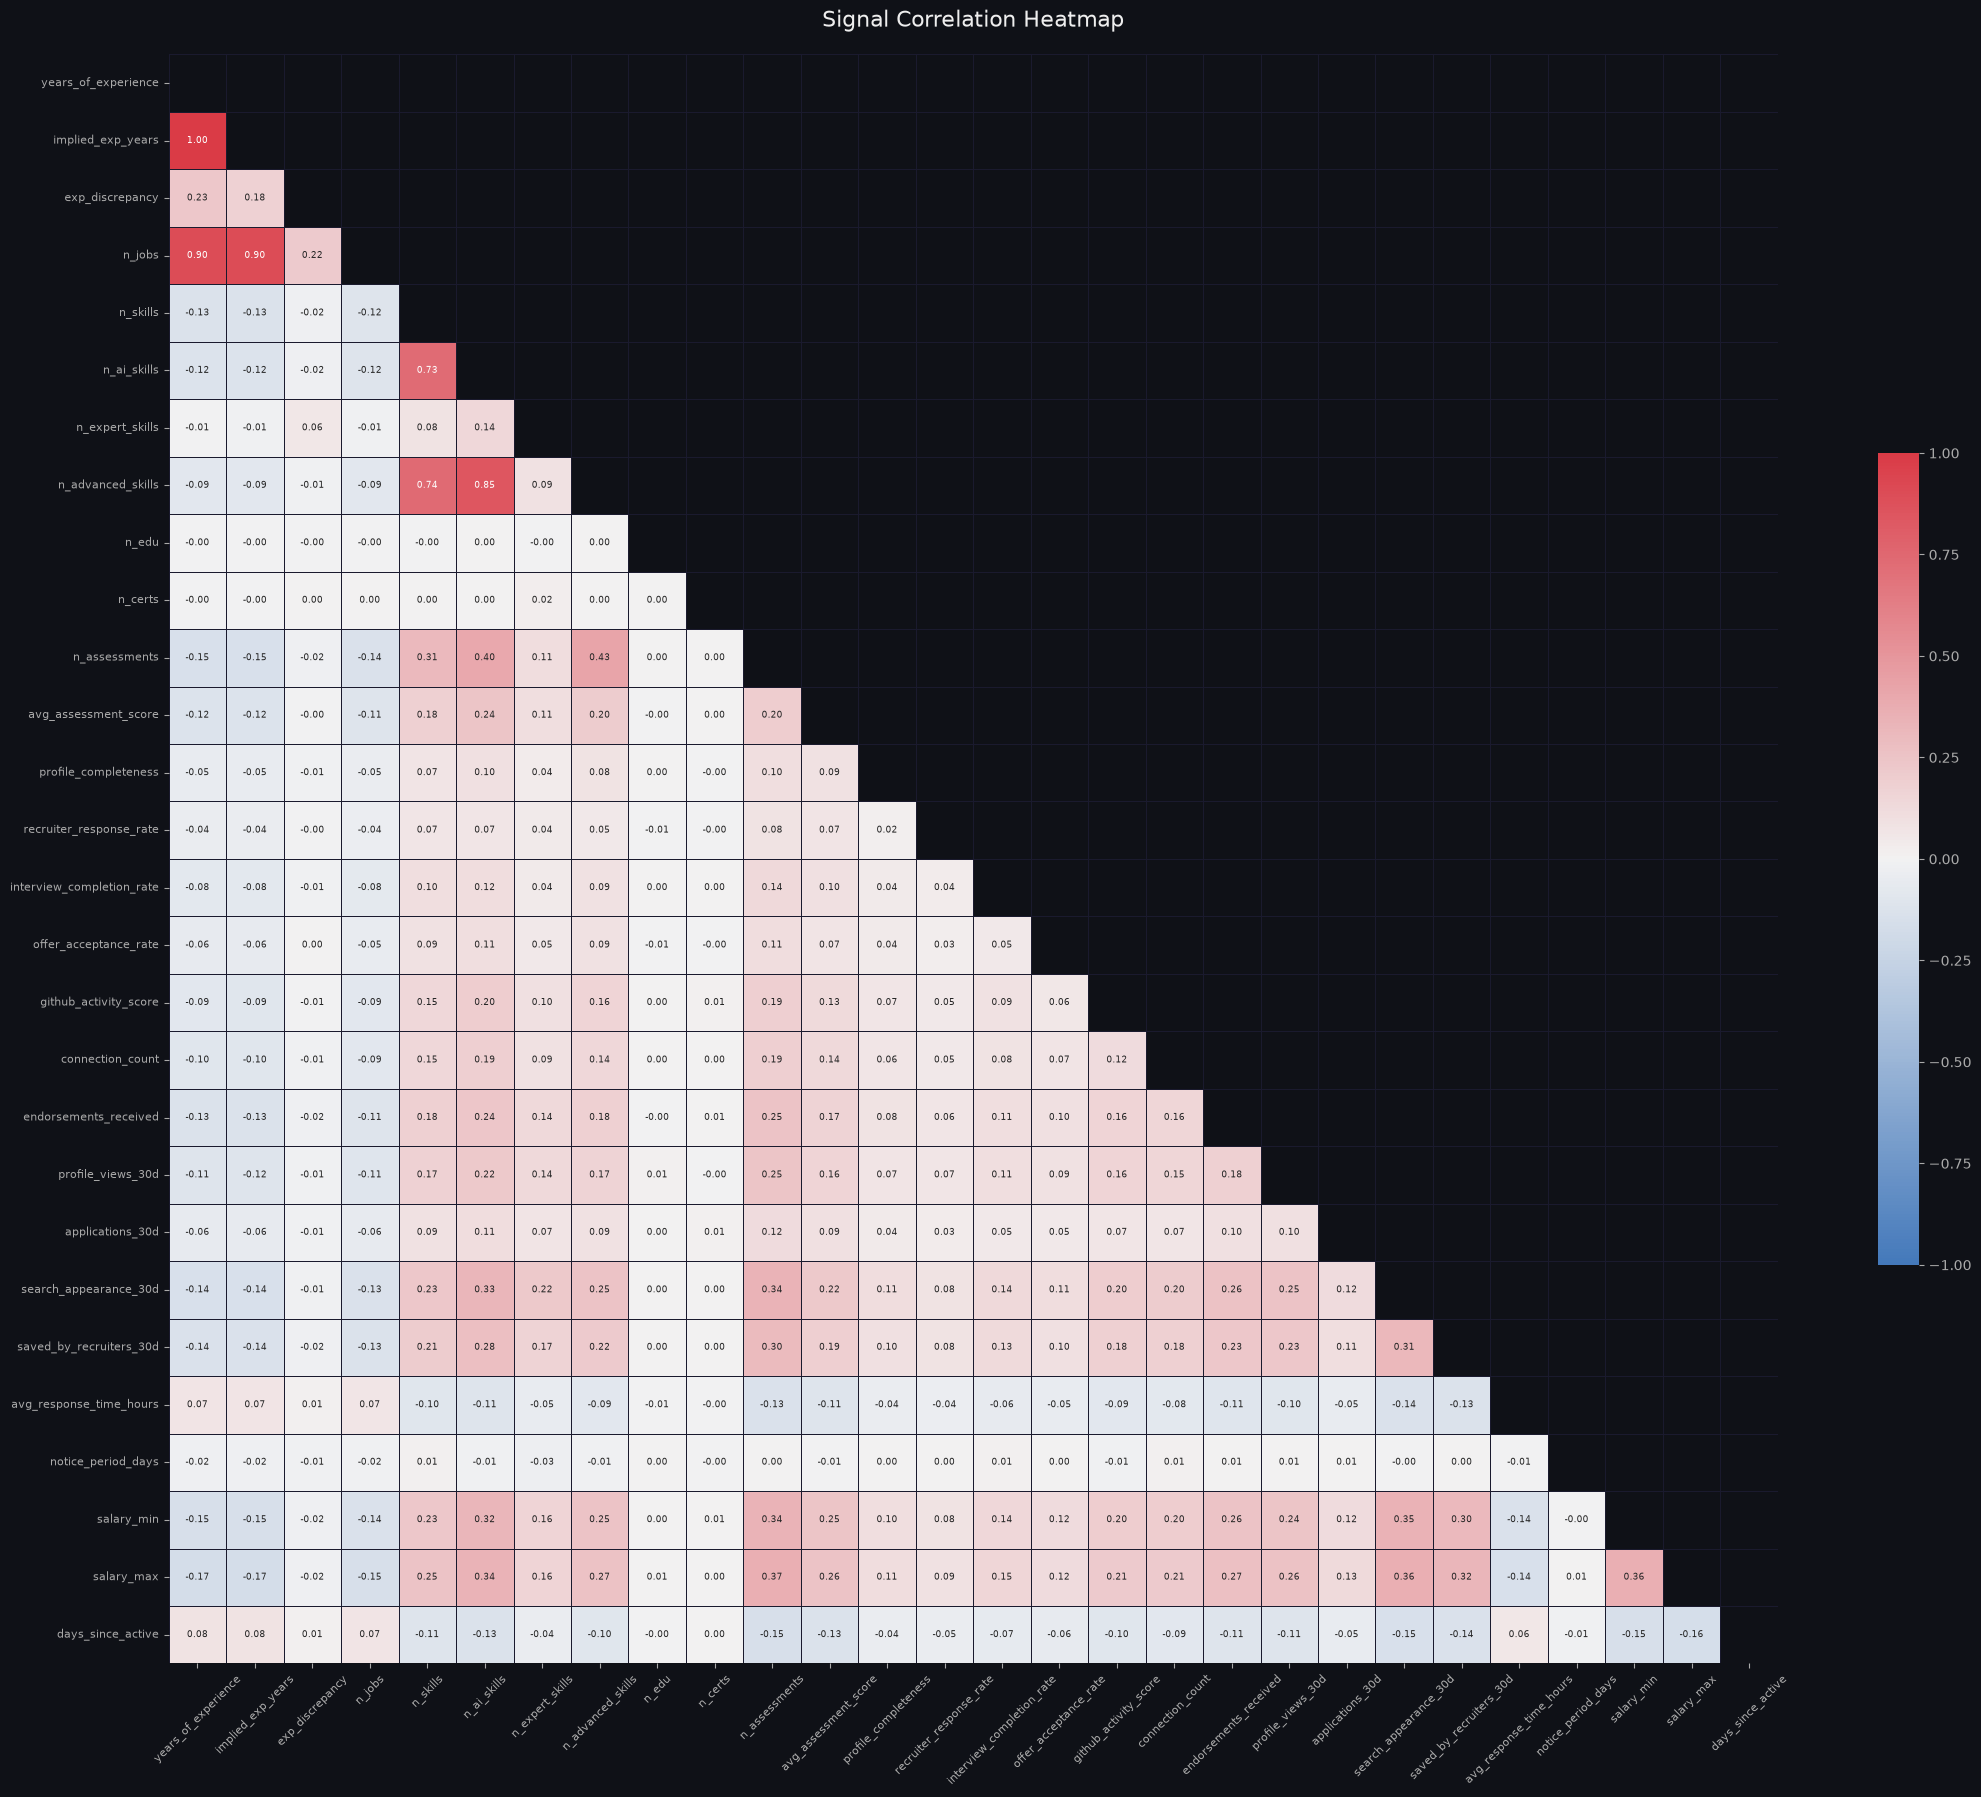

In [17]:
numeric_cols = [
    "years_of_experience","implied_exp_years","exp_discrepancy","n_jobs",
    "n_skills","n_ai_skills","n_expert_skills","n_advanced_skills",
    "n_edu","n_certs","n_assessments","avg_assessment_score",
    "profile_completeness","recruiter_response_rate","interview_completion_rate",
    "offer_acceptance_rate","github_activity_score","connection_count",
    "endorsements_received","profile_views_30d","applications_30d",
    "search_appearance_30d","saved_by_recruiters_30d","avg_response_time_hours",
    "notice_period_days","salary_min","salary_max","days_since_active",
]

corr_df = df[numeric_cols].replace(-1, np.nan).corr()

fig, ax = plt.subplots(figsize=(22, 18))
mask = np.zeros_like(corr_df, dtype=bool)
mask[np.triu_indices_from(mask)] = True

cmap = sns.diverging_palette(250, 10, as_cmap=True)
sns.heatmap(corr_df, mask=mask, cmap=cmap, center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 6.5},
            linewidths=0.4, linecolor="#1a1a2e",
            square=True, ax=ax,
            cbar_kws={"shrink": 0.5})

ax.set_title("Signal Correlation Heatmap", fontsize=16, pad=20, color="#eee")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()


## 15. Unusual Distribution & Outlier Patterns

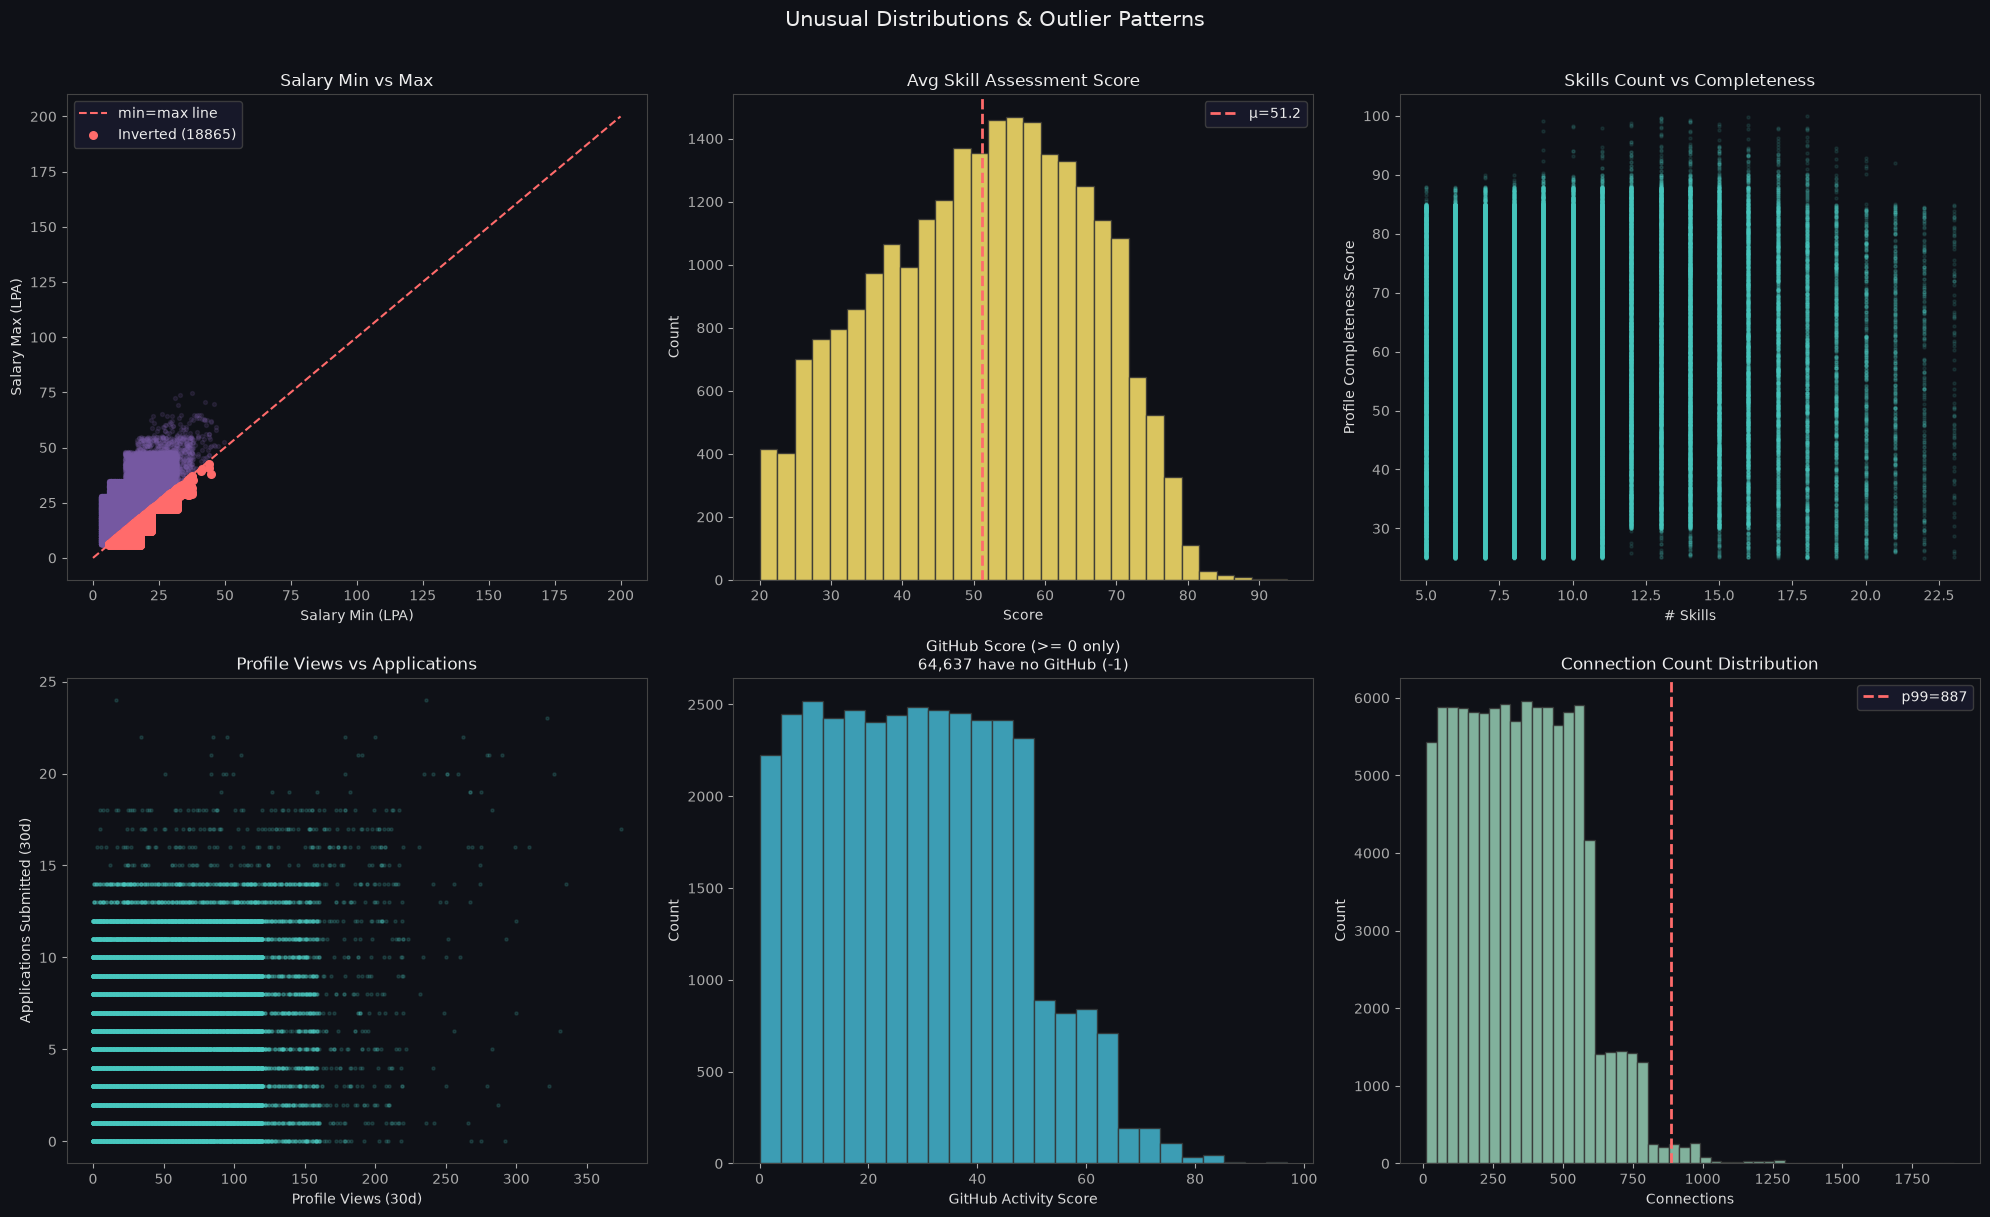

Salary inverted (max < min): 18865
Connection count > 1000   : 273
Applications > 15/month   : 219
Response time > 500 hrs   : 0
0 skills candidates       : 0


In [18]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Salary distribution
ax = axes[0, 0]
valid_sal = df[(df["salary_min"].notna()) & (df["salary_max"].notna())]
ax.scatter(valid_sal["salary_min"], valid_sal["salary_max"],
           alpha=0.15, c=ACCENT, s=8)
ax.plot([0, 200], [0, 200], color=WARN_CLR, linestyle="--", lw=1.5, label="min=max line")
ax.set_xlabel("Salary Min (LPA)"); ax.set_ylabel("Salary Max (LPA)")
ax.set_title("Salary Min vs Max", fontsize=12)
ax.legend()
# Flag inverted
inverted = valid_sal[valid_sal["salary_max"] < valid_sal["salary_min"]]
ax.scatter(inverted["salary_min"], inverted["salary_max"],
           c=WARN_CLR, s=30, zorder=5, label=f"Inverted ({len(inverted)})")
ax.legend()

# Assessment score distribution
ax = axes[0, 1]
data = df["avg_assessment_score"].dropna()
ax.hist(data, bins=30, color=PALETTE[3], edgecolor="#333", alpha=0.85)
ax.set_title("Avg Skill Assessment Score", fontsize=12)
ax.set_xlabel("Score"); ax.set_ylabel("Count")
ax.axvline(data.mean(), color=WARN_CLR, lw=2, linestyle="--", label=f"μ={data.mean():.1f}")
ax.legend()

# Profile completeness vs n_skills
ax = axes[0, 2]
ax.scatter(df["n_skills"], df["profile_completeness"], alpha=0.1, c=GOOD_CLR, s=5)
ax.set_xlabel("# Skills"); ax.set_ylabel("Profile Completeness Score")
ax.set_title("Skills Count vs Completeness", fontsize=12)

# Applications vs profile views
ax = axes[1, 0]
ax.scatter(df["profile_views_30d"], df["applications_30d"], alpha=0.15, c=PALETTE[1], s=5)
ax.set_xlabel("Profile Views (30d)"); ax.set_ylabel("Applications Submitted (30d)")
ax.set_title("Profile Views vs Applications", fontsize=12)

# GitHub activity score (0+ range only)
ax = axes[1, 1]
gh_pos = df[df["github_activity_score"] >= 0]["github_activity_score"]
gh_neg = (df["github_activity_score"] == -1).sum()
ax.hist(gh_pos, bins=25, color=PALETTE[4], edgecolor="#333", alpha=0.85)
ax.set_title(f"GitHub Score (>= 0 only)\n{gh_neg:,} have no GitHub (-1)", fontsize=11)
ax.set_xlabel("GitHub Activity Score"); ax.set_ylabel("Count")

# Connection count outliers
ax = axes[1, 2]
conns = df["connection_count"]
ax.hist(conns, bins=50, color=PALETTE[5], edgecolor="#333", alpha=0.85)
ax.set_title("Connection Count Distribution", fontsize=12)
ax.set_xlabel("Connections"); ax.set_ylabel("Count")
p99 = conns.quantile(0.99)
ax.axvline(p99, color=WARN_CLR, lw=2, linestyle="--", label=f"p99={p99:.0f}")
ax.legend()

plt.suptitle("Unusual Distributions & Outlier Patterns", fontsize=15, y=1.01, color="#eee")
plt.tight_layout()
plt.savefig("unusual_distributions.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

# Outlier summary
print(f"Salary inverted (max < min): {len(inverted)}")
print(f"Connection count > 1000   : {(df['connection_count']>1000).sum()}")
print(f"Applications > 15/month   : {(df['applications_30d']>15).sum()}")
print(f"Response time > 500 hrs   : {(df['avg_response_time_hours']>500).sum()}")
print(f"0 skills candidates       : {(df['n_skills']==0).sum()}")


## 16. Summary Dashboard

In [19]:
print("=" * 65)
print("       INDIA.RUNS 2026 — DATASET FORENSICS SUMMARY")
print("=" * 65)

n = len(candidates)
print(f"\n📊 DATASET SIZE")
print(f"   Total candidates          : {n:,}")
print(f"   Total skill entries       : {len(skills_df):,}")
print(f"   Total education records   : {len(edu_df):,}")
print(f"   Total job records         : {len(jobs_df):,}")
print(f"   JSON parse errors         : {len(parse_errors)}")

print(f"\n🌍 GEOGRAPHY")
top_countries = df['country'].value_counts().head(3)
for c, cnt in top_countries.items():
    print(f"   {c:<20s}: {cnt:,} ({cnt/n*100:.1f}%)")

print(f"\n📈 EXPERIENCE")
print(f"   YoE range                 : {df['years_of_experience'].min():.1f} – {df['years_of_experience'].max():.1f} years")
print(f"   Mean claimed YoE          : {df['years_of_experience'].mean():.1f} years")
print(f"   Mean implied YoE          : {df['implied_exp_years'].mean():.1f} years")
print(f"   High discrepancy (>5yr)   : {(df['exp_discrepancy'].abs()>5).sum():,} candidates")

print(f"\n🎓 EDUCATION")
tier1_pct = (df['highest_tier']=='tier_1').mean()*100
tier2_pct = (df['highest_tier']=='tier_2').mean()*100
tier3_pct = (df['highest_tier']=='tier_3').mean()*100
tier4_pct = (df['highest_tier']=='tier_4').mean()*100
print(f"   Tier-1 institutions       : {tier1_pct:.1f}%")
print(f"   Tier-2 institutions       : {tier2_pct:.1f}%")
print(f"   Tier-3 institutions       : {tier3_pct:.1f}%")
print(f"   Tier-4 institutions       : {tier4_pct:.1f}%")

print(f"\n🧠 AI SKILLS")
print(f"   Candidates with 0 AI skills: {(df['n_ai_skills']==0).sum():,} ({(df['n_ai_skills']==0).mean()*100:.1f}%)")
print(f"   Candidates with 5+ AI skills: {(df['n_ai_skills']>=5).sum():,} ({(df['n_ai_skills']>=5).mean()*100:.1f}%)")
print(f"   Candidates with 10+ AI skills: {(df['n_ai_skills']>=10).sum():,} ({(df['n_ai_skills']>=10).mean()*100:.1f}%)")

print(f"\n📡 REDROB SIGNALS")
print(f"   Open to work              : {df['open_to_work'].mean()*100:.1f}%")
print(f"   Verified email            : {df['verified_email'].mean()*100:.1f}%")
print(f"   GitHub linked             : {(df['github_activity_score']>-1).mean()*100:.1f}%")
print(f"   Willing to relocate       : {df['willing_to_relocate'].mean()*100:.1f}%")
print(f"   Avg recruiter response rate: {df['recruiter_response_rate'].mean():.3f}")
print(f"   Avg interview completion   : {df['interview_completion_rate'].mean():.3f}")

print(f"\n🍯 HONEYPOT INDICATORS")
print(f"   Flagged candidates        : {total_flagged:,} ({total_flagged/n*100:.1f}%)")
print(f"   Total flags raised        : {total_flags:,}")
for flag_type, count in flag_type_counts.most_common(5):
    print(f"   {flag_type:<35s}: {count:,}")

print(f"\n{'='*65}")
print("  Analysis complete. See data_profile_report.md for findings.")
print("=" * 65)


       INDIA.RUNS 2026 — DATASET FORENSICS SUMMARY

📊 DATASET SIZE
   Total candidates          : 100,000
   Total skill entries       : 960,302
   Total education records   : 139,778
   Total job records         : 300,171
   JSON parse errors         : 0

🌍 GEOGRAPHY
   India               : 75,113 (75.1%)
   USA                 : 9,978 (10.0%)
   Australia           : 2,579 (2.6%)

📈 EXPERIENCE
   YoE range                 : 1.0 – 16.9 years
   Mean claimed YoE          : 7.2 years
   Mean implied YoE          : 7.1 years
   High discrepancy (>5yr)   : 39 candidates

🎓 EDUCATION
   Tier-1 institutions       : 6.4%
   Tier-2 institutions       : 23.0%
   Tier-3 institutions       : 39.8%
   Tier-4 institutions       : 30.8%

🧠 AI SKILLS
   Candidates with 0 AI skills: 52,580 (52.6%)
   Candidates with 5+ AI skills: 6,381 (6.4%)
   Candidates with 10+ AI skills: 59 (0.1%)

📡 REDROB SIGNALS
   Open to work              : 35.3%
   Verified email            : 72.0%
   GitHub linked       